In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q datasets tokenizers matplotlib tqdm

In [3]:
import math
import copy
import time

import torch
import torch.nn as nn
import torch.nn.functional as F

print("Environment ready!")

Environment ready!


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

Using: cuda


# **1. Tokenization + Embeddings**






***Create a tiny toy vocabulary***

In [5]:
vocab = {
    "<pad>": 0,
    "<bos>": 1,
    "<eos>": 2,
    "i": 3,
    "love": 4,
    "artificial": 5,
    "intelligence": 6,
    "transformers": 7
}

print(vocab)
print("Vocabulary size:", len(vocab))

{'<pad>': 0, '<bos>': 1, '<eos>': 2, 'i': 3, 'love': 4, 'artificial': 5, 'intelligence': 6, 'transformers': 7}
Vocabulary size: 8


***Convert a sentence into token IDs***



In [6]:
sentence = ["i", "love", "transformers"]

token_ids = [vocab[word] for word in sentence]

print("Sentence:", sentence)
print("Token IDs:", token_ids)

Sentence: ['i', 'love', 'transformers']
Token IDs: [3, 4, 7]


# **Create an embedding layer**

In [7]:
import torch
import torch.nn as nn

vocab_size = len(vocab)

d_model = 8

embedding = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=d_model
)

print(embedding)

Embedding(8, 8)


# **Convert token IDs to a tensor**

In [8]:
tokens = torch.tensor(token_ids)

print(tokens)
print("Shape:", tokens.shape)

tensor([3, 4, 7])
Shape: torch.Size([3])


***Pass them through the embedding layer***

In [9]:
embedded_tokens = embedding(tokens)

print(embedded_tokens)
print("Shape:", embedded_tokens.shape)

tensor([[ 0.4574, -0.6765,  0.9948,  0.4747,  0.0382,  1.0437, -0.2986, -0.4513],
        [-1.4098,  0.8349, -0.9491,  0.0024, -1.2031, -0.3776, -0.0192,  0.1778],
        [ 0.0361,  1.5324,  1.0890, -1.8274, -1.2439, -0.1720,  2.2173,  0.0545]],
       grad_fn=<EmbeddingBackward0>)
Shape: torch.Size([3, 8])


***Look at one word embedding***

In [10]:
print("Token:", sentence[0])
print("Token ID:", token_ids[0])
print("Embedding:")

print(embedded_tokens[0])

Token: i
Token ID: 3
Embedding:
tensor([ 0.4574, -0.6765,  0.9948,  0.4747,  0.0382,  1.0437, -0.2986, -0.4513],
       grad_fn=<SelectBackward0>)


*Moving it to GPU*

In [11]:
embedding = embedding.to(device)
tokens = tokens.to(device)

embedded_tokens = embedding(tokens)

print("Tensor device:", embedded_tokens.device)
print("Shape:", embedded_tokens.shape)

Tensor device: cuda:0
Shape: torch.Size([3, 8])


In [12]:
import math

scaled_embeddings = embedded_tokens * math.sqrt(d_model)

print("Original first embedding:")
print(embedded_tokens[0])

print("\nScaled first embedding:")
print(scaled_embeddings[0])

Original first embedding:
tensor([ 0.4574, -0.6765,  0.9948,  0.4747,  0.0382,  1.0437, -0.2986, -0.4513],
       device='cuda:0', grad_fn=<SelectBackward0>)

Scaled first embedding:
tensor([ 1.2937, -1.9133,  2.8137,  1.3427,  0.1080,  2.9521, -0.8445, -1.2766],
       device='cuda:0', grad_fn=<SelectBackward0>)


# **2. Positional Encoding**

In [13]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(
            0, max_len, dtype=torch.float
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)

        return x + self.pe[:, :seq_len]

In [14]:
embedded_batch = scaled_embeddings.unsqueeze(0)

print("Before adding batch dimension:")
print(scaled_embeddings.shape)

print("\nAfter adding batch dimension:")
print(embedded_batch.shape)

Before adding batch dimension:
torch.Size([3, 8])

After adding batch dimension:
torch.Size([1, 3, 8])


In [15]:
positional_encoding = PositionalEncoding(
    d_model=d_model,
    max_len=100
).to(device)

encoded_tokens = positional_encoding(embedded_batch)

print("Input shape:", embedded_batch.shape)
print("Output shape:", encoded_tokens.shape)

Input shape: torch.Size([1, 3, 8])
Output shape: torch.Size([1, 3, 8])


In [16]:
print("Position 0:")
print(positional_encoding.pe[0, 0])

print("\nPosition 1:")
print(positional_encoding.pe[0, 1])

print("\nPosition 2:")
print(positional_encoding.pe[0, 2])

Position 0:
tensor([0., 1., 0., 1., 0., 1., 0., 1.], device='cuda:0')

Position 1:
tensor([0.8415, 0.5403, 0.0998, 0.9950, 0.0100, 0.9999, 0.0010, 1.0000],
       device='cuda:0')

Position 2:
tensor([ 0.9093, -0.4161,  0.1987,  0.9801,  0.0200,  0.9998,  0.0020,  1.0000],
       device='cuda:0')


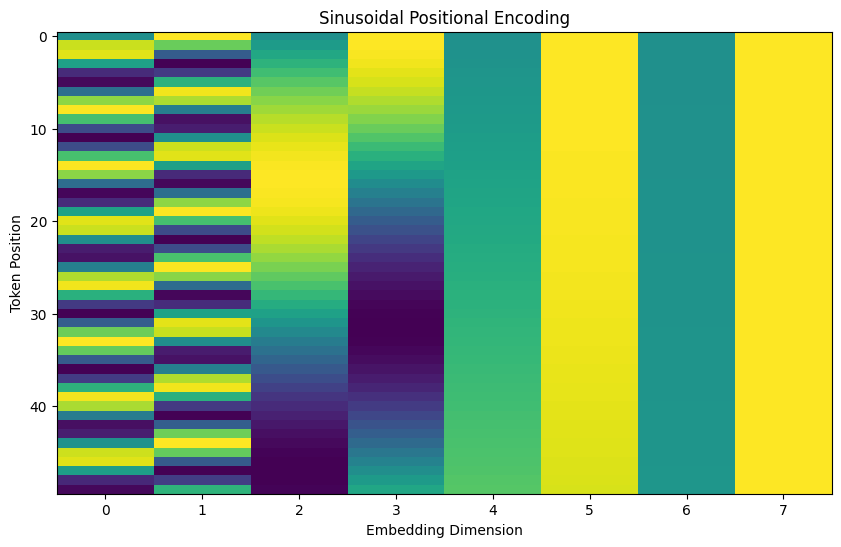

In [17]:
import matplotlib.pyplot as plt

pe_matrix = positional_encoding.pe[0, :50].cpu()

plt.figure(figsize=(10, 6))
plt.imshow(
    pe_matrix,
    aspect="auto"
)

plt.xlabel("Embedding Dimension")
plt.ylabel("Token Position")
plt.title("Sinusoidal Positional Encoding")

plt.show()

*Check that position changes the same token*

In [18]:
same_embedding = embedding(
    torch.tensor([3], device=device)
)

same_embedding = same_embedding * math.sqrt(d_model)

position_0 = (
    same_embedding
    + positional_encoding.pe[0, 0]
)

position_1 = (
    same_embedding
    + positional_encoding.pe[0, 1]
)

print("Same word at position 0:")
print(position_0)

print("\nSame word at position 1:")
print(position_1)

Same word at position 0:
tensor([[ 1.2937, -0.9133,  2.8137,  2.3427,  0.1080,  3.9521, -0.8445, -0.2766]],
       device='cuda:0', grad_fn=<AddBackward0>)

Same word at position 1:
tensor([[ 2.1352, -1.3730,  2.9135,  2.3377,  0.1180,  3.9521, -0.8435, -0.2766]],
       device='cuda:0', grad_fn=<AddBackward0>)


# **3. Scaled Dot-Product Attention**

*Create a tiny input for attention*

In [19]:
# Three tokens, each represented by 4 numbers
x = torch.tensor([
    [1.0, 0.0, 1.0, 0.0],
    [0.0, 2.0, 0.0, 2.0],
    [1.0, 1.0, 1.0, 1.0]
], device=device)

print("Input:")
print(x)

print("\nShape:", x.shape)

Input:
tensor([[1., 0., 1., 0.],
        [0., 2., 0., 2.],
        [1., 1., 1., 1.]], device='cuda:0')

Shape: torch.Size([3, 4])


*Create Q-QUERY , K-KEY, V-VALUE*



In [20]:
d_model_attention = 4

W_q = nn.Linear(
    d_model_attention,
    d_model_attention,
    bias=False
).to(device)

W_k = nn.Linear(
    d_model_attention,
    d_model_attention,
    bias=False
).to(device)

W_v = nn.Linear(
    d_model_attention,
    d_model_attention,
    bias=False
).to(device)

Q = W_q(x)
K = W_k(x)
V = W_v(x)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: torch.Size([3, 4])
K shape: torch.Size([3, 4])
V shape: torch.Size([3, 4])


***Calculate QKᵀ***

In [21]:
scores = torch.matmul(
    Q,
    K.transpose(-2, -1)
)

print("Attention scores:")
print(scores)

print("\nShape:", scores.shape)

Attention scores:
tensor([[-0.8346, -2.1906, -1.9299],
        [ 0.2617, -0.4924,  0.0155],
        [-0.7038, -2.4368, -1.9222]], device='cuda:0', grad_fn=<MmBackward0>)

Shape: torch.Size([3, 3])


*Scale the scores*

In [22]:
d_k = K.size(-1)

scaled_scores = scores / math.sqrt(d_k)

print("d_k:", d_k)

print("\nOriginal scores:")
print(scores)

print("\nScaled scores:")
print(scaled_scores)

d_k: 4

Original scores:
tensor([[-0.8346, -2.1906, -1.9299],
        [ 0.2617, -0.4924,  0.0155],
        [-0.7038, -2.4368, -1.9222]], device='cuda:0', grad_fn=<MmBackward0>)

Scaled scores:
tensor([[-0.4173, -1.0953, -0.9650],
        [ 0.1308, -0.2462,  0.0077],
        [-0.3519, -1.2184, -0.9611]], device='cuda:0', grad_fn=<DivBackward0>)


*Apply softmax*

In [23]:
attention_weights = F.softmax(
    scaled_scores,
    dim=-1
)

print("Attention weights:")
print(attention_weights)

Attention weights:
tensor([[0.4794, 0.2434, 0.2772],
        [0.3891, 0.2669, 0.3440],
        [0.5091, 0.2140, 0.2768]], device='cuda:0', grad_fn=<SoftmaxBackward0>)


In [24]:
print(
    "Row sums:",
    attention_weights.sum(dim=-1)
)

Row sums: tensor([1.0000, 1.0000, 1.0000], device='cuda:0', grad_fn=<SumBackward1>)


*Multiply by V*

In [25]:
attention_output = torch.matmul(
    attention_weights,
    V
)

print("Attention output:")
print(attention_output)

print("\nShape:")
print(attention_output.shape)

Attention output:
tensor([[-0.5968,  0.1606, -0.2790, -0.2969],
        [-0.6659,  0.1509, -0.2615, -0.2541],
        [-0.5635,  0.1699, -0.2954, -0.3301]], device='cuda:0',
       grad_fn=<MmBackward0>)

Shape:
torch.Size([3, 4])


In [26]:
def scaled_dot_product_attention(
    Q,
    K,
    V,
    mask=None
):
    d_k = Q.size(-1)

    scores = torch.matmul(
        Q,
        K.transpose(-2, -1)
    )

    scores = scores / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(
            mask == 0,
            float("-inf")
        )

    attention_weights = F.softmax(
        scores,
        dim=-1
    )

    output = torch.matmul(
        attention_weights,
        V
    )

    return output, attention_weights

In [27]:
output, weights = scaled_dot_product_attention(
    Q,
    K,
    V
)

print("Output:")
print(output)

print("\nAttention weights:")
print(weights)

print("\nOutput shape:")
print(output.shape)

print("\nWeight shape:")
print(weights.shape)

Output:
tensor([[-0.5968,  0.1606, -0.2790, -0.2969],
        [-0.6659,  0.1509, -0.2615, -0.2541],
        [-0.5635,  0.1699, -0.2954, -0.3301]], device='cuda:0',
       grad_fn=<MmBackward0>)

Attention weights:
tensor([[0.4794, 0.2434, 0.2772],
        [0.3891, 0.2669, 0.3440],
        [0.5091, 0.2140, 0.2768]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

Output shape:
torch.Size([3, 4])

Weight shape:
torch.Size([3, 3])


In [28]:
print(
    torch.allclose(
        attention_output,
        output
    )
)

True


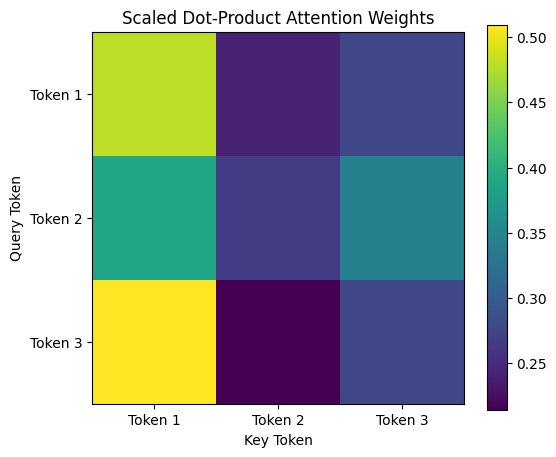

In [29]:
weights_cpu = weights.detach().cpu()

plt.figure(figsize=(6, 5))

plt.imshow(
    weights_cpu
)

plt.xlabel("Key Token")
plt.ylabel("Query Token")

plt.title(
    "Scaled Dot-Product Attention Weights"
)

plt.xticks(
    range(3),
    ["Token 1", "Token 2", "Token 3"]
)

plt.yticks(
    range(3),
    ["Token 1", "Token 2", "Token 3"]
)

plt.colorbar()

plt.show()

# **4.Multi-Head Attention**

*Set dimensions*

In [30]:
d_model = 8
num_heads = 2

assert d_model % num_heads == 0

d_k = d_model // num_heads

print("d_model:", d_model)
print("Number of heads:", num_heads)
print("Dimension per head:", d_k)

d_model: 8
Number of heads: 2
Dimension per head: 4


*Build MultiHeadAttention*

In [31]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Learned projections for Q, K and V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Final projection after concatenating the heads
        self.W_o = nn.Linear(d_model, d_model)

    def split_heads(self, x):

        batch_size = x.size(0)

        x = x.view(
            batch_size,
            -1,
            self.num_heads,
            self.d_k
        )

        return x.transpose(1, 2)

    def forward(
        self,
        query,
        key,
        value,
        mask=None
    ):

        # 1. Project input into Q, K and V
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # 2. Split Q, K and V into multiple heads
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # 3. Apply the attention function we already wrote
        attention_output, attention_weights = (
            scaled_dot_product_attention(
                Q,
                K,
                V,
                mask
            )
        )

        # 4. Put all heads back together
        attention_output = attention_output.transpose(
            1, 2
        ).contiguous()

        batch_size = attention_output.size(0)

        attention_output = attention_output.view(
            batch_size,
            -1,
            self.d_model
        )

        # 5. Final learned projection
        output = self.W_o(attention_output)

        return output, attention_weights

*Create the MHA layer*

In [32]:
multi_head_attention = MultiHeadAttention(
    d_model=8,
    num_heads=2
).to(device)

print(multi_head_attention)

MultiHeadAttention(
  (W_q): Linear(in_features=8, out_features=8, bias=True)
  (W_k): Linear(in_features=8, out_features=8, bias=True)
  (W_v): Linear(in_features=8, out_features=8, bias=True)
  (W_o): Linear(in_features=8, out_features=8, bias=True)
)


In [33]:
encoded_tokens

tensor([[[ 1.2937, -0.9133,  2.8137,  2.3427,  0.1080,  3.9521, -0.8445,
          -0.2766],
         [-3.1459,  2.9017, -2.5845,  1.0019, -3.3930, -0.0680, -0.0534,
           1.5028],
         [ 1.0113,  3.9182,  3.2787, -4.1887, -3.4983,  0.5132,  6.2736,
           1.1541]]], device='cuda:0', grad_fn=<AddBackward0>)

In [34]:
print("Input shape:")
print(encoded_tokens.shape)

Input shape:
torch.Size([1, 3, 8])


In [35]:
mha_output, mha_weights = multi_head_attention(
    encoded_tokens,
    encoded_tokens,
    encoded_tokens
)

print("MHA output shape:")
print(mha_output.shape)

print("\nAttention weights shape:")
print(mha_weights.shape)

MHA output shape:
torch.Size([1, 3, 8])

Attention weights shape:
torch.Size([1, 2, 3, 3])


In [36]:
print(
    mha_weights.sum(dim=-1)
)

tensor([[[1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000]]], device='cuda:0', grad_fn=<SumBackward1>)


In [37]:
print("HEAD 1")
print(mha_weights[0, 0])

print("\nHEAD 2")
print(mha_weights[0, 1])

HEAD 1
tensor([[0.6738, 0.2579, 0.0683],
        [0.5953, 0.3998, 0.0049],
        [0.0207, 0.1148, 0.8645]], device='cuda:0', grad_fn=<SelectBackward0>)

HEAD 2
tensor([[1.7086e-01, 1.5005e-01, 6.7909e-01],
        [7.7161e-01, 2.9954e-02, 1.9844e-01],
        [3.4984e-04, 3.1903e-03, 9.9646e-01]], device='cuda:0',
       grad_fn=<SelectBackward0>)


*Visualize Head1*

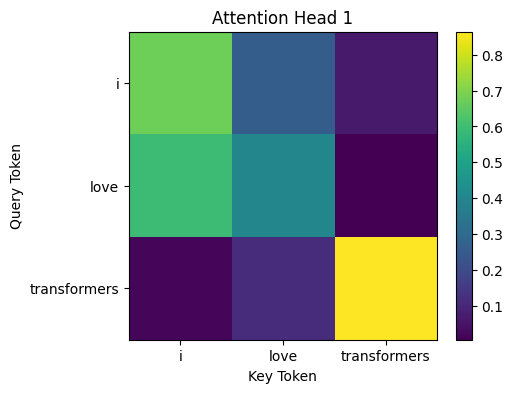

In [38]:
head1 = mha_weights[0, 0].detach().cpu()

plt.figure(figsize=(5, 4))

plt.imshow(head1)

plt.title("Attention Head 1")
plt.xlabel("Key Token")
plt.ylabel("Query Token")

plt.xticks(
    range(3),
    sentence
)

plt.yticks(
    range(3),
    sentence
)

plt.colorbar()

plt.show()

*Visualize head2*

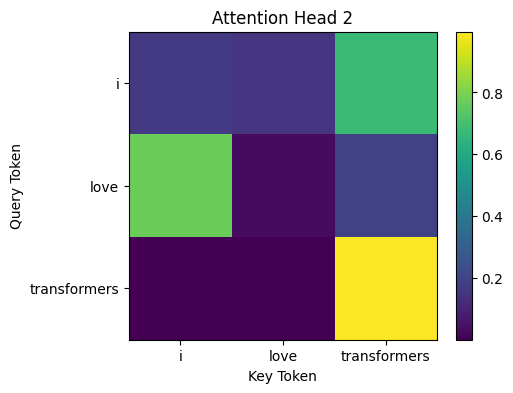

In [39]:
head2 = mha_weights[0, 1].detach().cpu()

plt.figure(figsize=(5, 4))

plt.imshow(head2)

plt.title("Attention Head 2")
plt.xlabel("Key Token")
plt.ylabel("Query Token")

plt.xticks(
    range(3),
    sentence
)

plt.yticks(
    range(3),
    sentence
)

plt.colorbar()

plt.show()

*Check gradients*

In [40]:

loss = mha_output.sum()

loss.backward()

print(
    "W_q gradient exists:",
    multi_head_attention.W_q.weight.grad is not None
)

print(
    "W_k gradient exists:",
    multi_head_attention.W_k.weight.grad is not None
)

print(
    "W_v gradient exists:",
    multi_head_attention.W_v.weight.grad is not None
)

W_q gradient exists: True
W_k gradient exists: True
W_v gradient exists: True


# **5. Feed-Forward Network**

*Position-wise FFN*

In [41]:
class FeedForward(nn.Module):

    def __init__(self, d_model, d_ff):
        super().__init__()

        self.linear1 = nn.Linear(
            d_model,
            d_ff
        )

        self.linear2 = nn.Linear(
            d_ff,
            d_model
        )

    def forward(self, x):

        x = self.linear1(x)

        x = F.relu(x)

        x = self.linear2(x)

        return x

In [42]:
d_ff = 32

ffn = FeedForward(
    d_model=8,
    d_ff=d_ff
).to(device)

ffn_output = ffn(mha_output)

print("Input shape:")
print(mha_output.shape)

print("\nFFN output shape:")
print(ffn_output.shape)

Input shape:
torch.Size([1, 3, 8])

FFN output shape:
torch.Size([1, 3, 8])


# **6. Residual Connections**

In [43]:
residual_output = encoded_tokens + mha_output

print("Original input shape:")
print(encoded_tokens.shape)

print("\nAttention output shape:")
print(mha_output.shape)

print("\nAfter residual connection:")
print(residual_output.shape)

Original input shape:
torch.Size([1, 3, 8])

Attention output shape:
torch.Size([1, 3, 8])

After residual connection:
torch.Size([1, 3, 8])


# **7. Layer Normalization**

*Test layernorm*

In [44]:
layer_norm = nn.LayerNorm(
    d_model
).to(device)

normalized_output = layer_norm(
    residual_output
)

print("Before LayerNorm:")
print(residual_output.shape)

print("\nAfter LayerNorm:")
print(normalized_output.shape)

Before LayerNorm:
torch.Size([1, 3, 8])

After LayerNorm:
torch.Size([1, 3, 8])


*Add dropout*

In [45]:
dropout_rate = 0.1

In [46]:
dropout = nn.Dropout(dropout_rate)

print(dropout)

Dropout(p=0.1, inplace=False)


# **8. Transformer Encoder Layer**

*Build EncoderLayer*

In [47]:
class EncoderLayer(nn.Module):

    def __init__(
        self,
        d_model,
        num_heads,
        d_ff,
        dropout=0.1
    ):
        super().__init__()

        # Multi-head self-attention
        self.self_attention = MultiHeadAttention(
            d_model,
            num_heads
        )

        # Position-wise feed-forward network
        self.feed_forward = FeedForward(
            d_model,
            d_ff
        )

        # Two LayerNorms
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        # Two dropout layers
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(
        self,
        x,
        mask=None
    ):

        # ----- Sublayer 1: Multi-Head Self-Attention -----

        attention_output, attention_weights = (
            self.self_attention(
                x,
                x,
                x,
                mask
            )
        )

        # Dropout
        attention_output = self.dropout1(
            attention_output
        )

        # Residual connection + LayerNorm
        x = self.norm1(
            x + attention_output
        )


        # ----- Sublayer 2: Feed-Forward Network -----

        ffn_output = self.feed_forward(x)

        # Dropout
        ffn_output = self.dropout2(
            ffn_output
        )

        # Residual connection + LayerNorm
        x = self.norm2(
            x + ffn_output
        )

        return x, attention_weights

*Instantiate first Encoder Layer*

In [48]:
encoder_layer = EncoderLayer(
    d_model=8,
    num_heads=2,
    d_ff=32,
    dropout=0.1
).to(device)

print(encoder_layer)

EncoderLayer(
  (self_attention): MultiHeadAttention(
    (W_q): Linear(in_features=8, out_features=8, bias=True)
    (W_k): Linear(in_features=8, out_features=8, bias=True)
    (W_v): Linear(in_features=8, out_features=8, bias=True)
    (W_o): Linear(in_features=8, out_features=8, bias=True)
  )
  (feed_forward): FeedForward(
    (linear1): Linear(in_features=8, out_features=32, bias=True)
    (linear2): Linear(in_features=32, out_features=8, bias=True)
  )
  (norm1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)


*Pass sentence through it*

In [49]:
encoder_output, encoder_attention = encoder_layer(
    encoded_tokens
)

print("Encoder input:")
print(encoded_tokens.shape)

print("\nEncoder output:")
print(encoder_output.shape)

print("\nAttention weights:")
print(encoder_attention.shape)

Encoder input:
torch.Size([1, 3, 8])

Encoder output:
torch.Size([1, 3, 8])

Attention weights:
torch.Size([1, 2, 3, 3])


In [50]:
print(
    "Contains NaN:",
    torch.isnan(encoder_output).any().item()
)

print(
    "Contains infinity:",
    torch.isinf(encoder_output).any().item()
)

Contains NaN: False
Contains infinity: False


In [51]:
print(
    "Mean:",
    encoder_output.mean().item()
)

print(
    "Standard deviation:",
    encoder_output.std().item()
)

Mean: -1.9868215517249155e-08
Standard deviation: 1.0215034484863281



*Check gradient flow through the whole encoder*



In [52]:

encoder_layer.zero_grad()


# Create a fresh forward pass so PyTorch builds a new computation graph
fresh_encoder_output, _ = encoder_layer(
    encoded_tokens.detach()
)

# Simple test loss
test_loss = fresh_encoder_output.pow(2).mean()

# Backpropagate through this fresh graph
test_loss.backward()

print(
    "Attention gradient exists:",
    encoder_layer.self_attention.W_q.weight.grad is not None
)

print(
    "FFN gradient exists:",
    encoder_layer.feed_forward.linear1.weight.grad is not None
)

print(
    "Attention gradient norm:",
    encoder_layer.self_attention.W_q.weight.grad.norm().item()
)

print(
    "FFN gradient norm:",
    encoder_layer.feed_forward.linear1.weight.grad.norm().item()
)

Attention gradient exists: True
FFN gradient exists: True
Attention gradient norm: 1.974261977011338e-06
FFN gradient norm: 4.498326688917587e-06


# **9. Stacked Transformer Encoder**

In [53]:
import copy

In [54]:
class Encoder(nn.Module):

    def __init__(
        self,
        encoder_layer,
        num_layers
    ):
        super().__init__()

        self.layers = nn.ModuleList([
            copy.deepcopy(encoder_layer)
            for _ in range(num_layers)
        ])

        self.num_layers = num_layers

    def forward(
        self,
        x,
        mask=None
    ):

        attention_maps = []

        for layer in self.layers:

            x, attention_weights = layer(
                x,
                mask
            )

            attention_maps.append(
                attention_weights
            )

        return x, attention_maps

*Create a 2-layer Encoder*

In [55]:
base_encoder_layer = EncoderLayer(
    d_model=8,
    num_heads=2,
    d_ff=32,
    dropout=0.1
)

encoder = Encoder(
    encoder_layer=base_encoder_layer,
    num_layers=2
).to(device)

print(encoder)

Encoder(
  (layers): ModuleList(
    (0-1): 2 x EncoderLayer(
      (self_attention): MultiHeadAttention(
        (W_q): Linear(in_features=8, out_features=8, bias=True)
        (W_k): Linear(in_features=8, out_features=8, bias=True)
        (W_v): Linear(in_features=8, out_features=8, bias=True)
        (W_o): Linear(in_features=8, out_features=8, bias=True)
      )
      (feed_forward): FeedForward(
        (linear1): Linear(in_features=8, out_features=32, bias=True)
        (linear2): Linear(in_features=32, out_features=8, bias=True)
      )
      (norm1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
  )
)


*Verify the layers do NOT share parameters*

In [56]:
same_parameter = (
    encoder.layers[0]
    .self_attention
    .W_q
    .weight
    is
    encoder.layers[1]
    .self_attention
    .W_q
    .weight
)

print(
    "Do Layer 1 and Layer 2 share W_q?",
    same_parameter
)

Do Layer 1 and Layer 2 share W_q? False


In [57]:
encoder.eval()

with torch.no_grad():

    stacked_output, stacked_attention = encoder(
        encoded_tokens.detach()
    )

print(
    "Input shape:",
    encoded_tokens.shape
)

print(
    "Final encoder output shape:",
    stacked_output.shape
)

print(
    "Number of encoder layers:",
    len(stacked_attention)
)

Input shape: torch.Size([1, 3, 8])
Final encoder output shape: torch.Size([1, 3, 8])
Number of encoder layers: 2


*Inspect attention from each layer*

In [58]:
for layer_index, attention in enumerate(
    stacked_attention
):

    print(
        f"Layer {layer_index + 1} attention shape:",
        attention.shape
    )

Layer 1 attention shape: torch.Size([1, 2, 3, 3])
Layer 2 attention shape: torch.Size([1, 2, 3, 3])


 *Visualize Layer 1, Head 1*

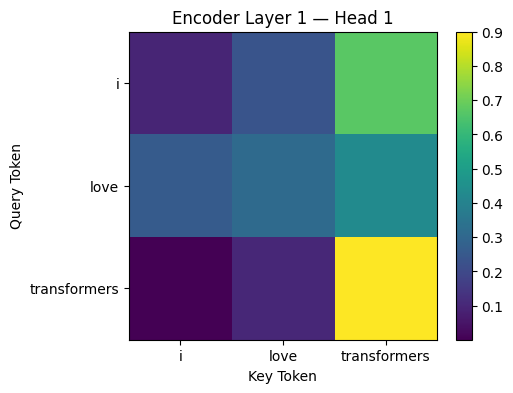

In [59]:
layer1_head1 = (
    stacked_attention[0][0, 0]
    .detach()
    .cpu()
)

plt.figure(figsize=(5, 4))

plt.imshow(layer1_head1)

plt.title(
    "Encoder Layer 1 — Head 1"
)

plt.xlabel("Key Token")
plt.ylabel("Query Token")

plt.xticks(
    range(len(sentence)),
    sentence
)

plt.yticks(
    range(len(sentence)),
    sentence
)

plt.colorbar()

plt.show()

*Layer 2, Head 1*

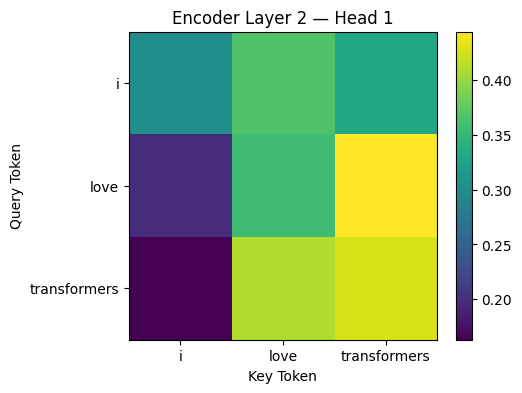

In [60]:
layer2_head1 = (
    stacked_attention[1][0, 0]
    .detach()
    .cpu()
)

plt.figure(figsize=(5, 4))

plt.imshow(layer2_head1)

plt.title(
    "Encoder Layer 2 — Head 1"
)

plt.xlabel("Key Token")
plt.ylabel("Query Token")

plt.xticks(
    range(len(sentence)),
    sentence
)

plt.yticks(
    range(len(sentence)),
    sentence
)

plt.colorbar()

plt.show()

*Count parameters*

In [61]:
total_params = sum(
    p.numel()
    for p in encoder.parameters()
)

trainable_params = sum(
    p.numel()
    for p in encoder.parameters()
    if p.requires_grad
)

print(
    "Total parameters:",
    total_params
)

print(
    "Trainable parameters:",
    trainable_params
)

Total parameters: 1744
Trainable parameters: 1744


*Test a fresh backward pass through ALL encoder layers*

In [62]:
encoder.train()

encoder.zero_grad()

fresh_input = encoded_tokens.detach()

fresh_output, _ = encoder(
    fresh_input
)

test_loss = fresh_output.pow(2).mean()

test_loss.backward()

In [63]:
print(
    "Layer 1 attention gradient:",
    encoder.layers[0]
    .self_attention
    .W_q
    .weight
    .grad is not None
)

print(
    "Layer 2 attention gradient:",
    encoder.layers[1]
    .self_attention
    .W_q
    .weight
    .grad is not None
)

print(
    "Layer 1 FFN gradient:",
    encoder.layers[0]
    .feed_forward
    .linear1
    .weight
    .grad is not None
)

print(
    "Layer 2 FFN gradient:",
    encoder.layers[1]
    .feed_forward
    .linear1
    .weight
    .grad is not None
)

Layer 1 attention gradient: True
Layer 2 attention gradient: True
Layer 1 FFN gradient: True
Layer 2 FFN gradient: True


*Build EncoderModel*

In [64]:
class EncoderModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_layers,
        max_len=5000,
        dropout=0.1
    ):
        super().__init__()

        self.d_model = d_model

        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.positional_encoding = (
            PositionalEncoding(
                d_model,
                max_len
            )
        )

        base_layer = EncoderLayer(
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout
        )

        self.encoder = Encoder(
            encoder_layer=base_layer,
            num_layers=num_layers
        )

    def forward(
        self,
        src,
        mask=None
    ):

        x = self.embedding(src)

        x = x * math.sqrt(
            self.d_model
        )

        x = self.positional_encoding(x)

        x, attention_maps = self.encoder(
            x,
            mask
        )

        return x, attention_maps

In [65]:
encoder_model = EncoderModel(
    vocab_size=len(vocab),
    d_model=8,
    num_heads=2,
    d_ff=32,
    num_layers=2,
    max_len=100,
    dropout=0.1
).to(device)

print(encoder_model)

EncoderModel(
  (embedding): Embedding(8, 8)
  (positional_encoding): PositionalEncoding()
  (encoder): Encoder(
    (layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (W_q): Linear(in_features=8, out_features=8, bias=True)
          (W_k): Linear(in_features=8, out_features=8, bias=True)
          (W_v): Linear(in_features=8, out_features=8, bias=True)
          (W_o): Linear(in_features=8, out_features=8, bias=True)
        )
        (feed_forward): FeedForward(
          (linear1): Linear(in_features=8, out_features=32, bias=True)
          (linear2): Linear(in_features=32, out_features=8, bias=True)
        )
        (norm1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
)


In [66]:
token_ids

[3, 4, 7]

In [67]:
src_tokens = torch.tensor(
    [token_ids],
    dtype=torch.long,
    device=device
)

print(src_tokens)

print(
    "Input shape:",
    src_tokens.shape
)

tensor([[3, 4, 7]], device='cuda:0')
Input shape: torch.Size([1, 3])


*Pass raw token IDs through your Encoder*

In [68]:
encoder_model.eval()

with torch.no_grad():

    final_encoder_output, attention_maps = (
        encoder_model(
            src_tokens
        )
    )

print(
    "Raw tokens:",
    src_tokens.shape
)

print(
    "Encoder representations:",
    final_encoder_output.shape
)

print(
    "Number of layers:",
    len(attention_maps)
)

Raw tokens: torch.Size([1, 3])
Encoder representations: torch.Size([1, 3, 8])
Number of layers: 2


# **10.Causal Masking**

*Create a causal mask*

In [69]:
def create_causal_mask(seq_len, device):

    mask = torch.tril(
        torch.ones(
            seq_len,
            seq_len,
            device=device
        )
    )

    return mask

In [70]:
causal_mask = create_causal_mask(
    seq_len=5,
    device=device
)

print(causal_mask)

tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]], device='cuda:0')


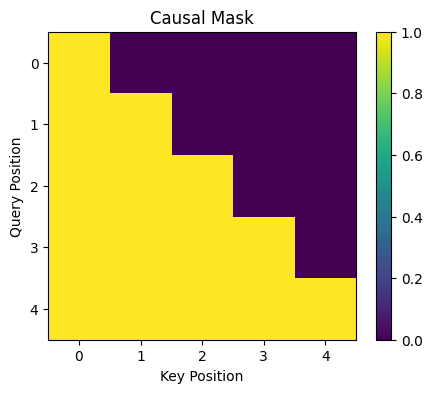

In [71]:
plt.figure(figsize=(5, 4))

plt.imshow(
    causal_mask.detach().cpu()
)

plt.title("Causal Mask")
plt.xlabel("Key Position")
plt.ylabel("Query Position")

plt.colorbar()

plt.show()

In [72]:
test_x = torch.randn(
    1,
    5,
    8,
    device=device
)

test_mha = MultiHeadAttention(
    d_model=8,
    num_heads=2
).to(device)

masked_output, masked_weights = test_mha(
    test_x,
    test_x,
    test_x,
    mask=causal_mask
)

print(
    "Output shape:",
    masked_output.shape
)

print(
    "Attention shape:",
    masked_weights.shape
)

Output shape: torch.Size([1, 5, 8])
Attention shape: torch.Size([1, 2, 5, 5])


*verify future attention is zero*

In [73]:
print(
    masked_weights[0, 0]
)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3176, 0.6824, 0.0000, 0.0000, 0.0000],
        [0.2820, 0.4292, 0.2888, 0.0000, 0.0000],
        [0.1521, 0.2400, 0.4072, 0.2006, 0.0000],
        [0.2660, 0.1712, 0.2658, 0.1161, 0.1810]], device='cuda:0',
       grad_fn=<SelectBackward0>)


In [74]:
future_positions = torch.triu(
    torch.ones(
        5,
        5,
        device=device
    ),
    diagonal=1
).bool()

future_attention = masked_weights[
    0,
    0
][future_positions]

print(
    "Maximum future attention:",
    future_attention.max().item()
)

Maximum future attention: 0.0


# **11. Decoder Layer**

*Create DecoderLayer*

In [75]:
class DecoderLayer(nn.Module):

    def __init__(
        self,
        d_model,
        num_heads,
        d_ff,
        dropout=0.1
    ):
        super().__init__()

        # 1. Masked self-attention
        self.self_attention = MultiHeadAttention(
            d_model,
            num_heads
        )

        # 2. Encoder-decoder cross-attention
        self.cross_attention = MultiHeadAttention(
            d_model,
            num_heads
        )

        # 3. Feed-forward network
        self.feed_forward = FeedForward(
            d_model,
            d_ff
        )

        # Three LayerNorms
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        # Three dropout layers
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(
        self,
        x,
        encoder_output,
        tgt_mask=None,
        src_mask=None
    ):

        # ----- Sublayer 1: Masked Self-Attention -----

        self_attn_output, self_attn_weights = (
            self.self_attention(
                x,
                x,
                x,
                tgt_mask
            )
        )

        self_attn_output = self.dropout1(
            self_attn_output
        )

        x = self.norm1(
            x + self_attn_output
        )


        # ----- Sublayer 2: Cross-Attention -----

        cross_attn_output, cross_attn_weights = (
            self.cross_attention(
                x,
                encoder_output,
                encoder_output,
                src_mask
            )
        )

        cross_attn_output = self.dropout2(
            cross_attn_output
        )

        x = self.norm2(
            x + cross_attn_output
        )


        # ----- Sublayer 3: Feed-Forward Network -----

        ffn_output = self.feed_forward(x)

        ffn_output = self.dropout3(
            ffn_output
        )

        x = self.norm3(
            x + ffn_output
        )

        return (
            x,
            self_attn_weights,
            cross_attn_weights
        )

In [76]:
decoder_layer = DecoderLayer(
    d_model=8,
    num_heads=2,
    d_ff=32,
    dropout=0.1
).to(device)

print(decoder_layer)

DecoderLayer(
  (self_attention): MultiHeadAttention(
    (W_q): Linear(in_features=8, out_features=8, bias=True)
    (W_k): Linear(in_features=8, out_features=8, bias=True)
    (W_v): Linear(in_features=8, out_features=8, bias=True)
    (W_o): Linear(in_features=8, out_features=8, bias=True)
  )
  (cross_attention): MultiHeadAttention(
    (W_q): Linear(in_features=8, out_features=8, bias=True)
    (W_k): Linear(in_features=8, out_features=8, bias=True)
    (W_v): Linear(in_features=8, out_features=8, bias=True)
    (W_o): Linear(in_features=8, out_features=8, bias=True)
  )
  (feed_forward): FeedForward(
    (linear1): Linear(in_features=8, out_features=32, bias=True)
    (linear2): Linear(in_features=32, out_features=8, bias=True)
  )
  (norm1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  (norm3): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropo

*Create dummy target representations*

In [77]:
target_vocab = {
    "<pad>": 0,
    "<bos>": 1,
    "<eos>": 2,
    "i": 3,
    "love": 4,
    "ai": 5
}

target_ids = [
    target_vocab["<bos>"],
    target_vocab["i"],
    target_vocab["love"]
]

target_tokens = torch.tensor(
    [target_ids],
    dtype=torch.long,
    device=device
)

print(target_tokens)
print(target_tokens.shape)

tensor([[1, 3, 4]], device='cuda:0')
torch.Size([1, 3])


*Create temporary target embeddings*

In [78]:
target_embedding = nn.Embedding(
    len(target_vocab),
    8
).to(device)

target_positional_encoding = PositionalEncoding(
    d_model=8,
    max_len=100
).to(device)

target_x = target_embedding(
    target_tokens
)

target_x = target_x * math.sqrt(8)

target_x = target_positional_encoding(
    target_x
)

print(target_x.shape)

torch.Size([1, 3, 8])


*Generate target causal mask*

In [79]:
tgt_mask = create_causal_mask(
    seq_len=target_tokens.size(1),
    device=device
)

print(tgt_mask)

tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]], device='cuda:0')


In [80]:
final_encoder_output

tensor([[[-0.0386, -0.4882, -1.7811,  1.0005,  0.1380,  1.8254, -0.4301,
          -0.2259],
         [ 0.0050,  2.2145,  0.0571,  0.3525, -0.9517, -1.3093, -0.5586,
           0.1906],
         [ 1.2034,  0.2873, -2.2499, -0.8289,  0.3875,  0.1649,  0.4614,
           0.5743]]], device='cuda:0')

In [81]:
decoder_layer.eval()

with torch.no_grad():

    decoder_output, decoder_self_attn, decoder_cross_attn = (
        decoder_layer(
            target_x,
            final_encoder_output,
            tgt_mask=tgt_mask
        )
    )

print(
    "Decoder output:",
    decoder_output.shape
)

print(
    "Decoder self-attention:",
    decoder_self_attn.shape
)

print(
    "Cross-attention:",
    decoder_cross_attn.shape
)

Decoder output: torch.Size([1, 3, 8])
Decoder self-attention: torch.Size([1, 2, 3, 3])
Cross-attention: torch.Size([1, 2, 3, 3])


*Verify decoder cannot see future target tokens*

In [82]:
future_positions = torch.triu(
    torch.ones(
        3,
        3,
        device=device
    ),
    diagonal=1
).bool()

future_decoder_attention = (
    decoder_self_attn[0, 0][future_positions]
)

print(
    "Max forbidden future attention:",
    future_decoder_attention.max().item()
)

Max forbidden future attention: 0.0


In [83]:
print(
    "Cross-attention Head 1:"
)

print(
    decoder_cross_attn[0, 0]
)

Cross-attention Head 1:
tensor([[0.2779, 0.3995, 0.3225],
        [0.3950, 0.2701, 0.3349],
        [0.3206, 0.3622, 0.3171]], device='cuda:0')


# **12. Stack the Decoder Layers**

In [84]:
class Decoder(nn.Module):

    def __init__(
        self,
        decoder_layer,
        num_layers
    ):
        super().__init__()

        self.layers = nn.ModuleList([
            copy.deepcopy(decoder_layer)
            for _ in range(num_layers)
        ])

        self.num_layers = num_layers

    def forward(
        self,
        x,
        encoder_output,
        tgt_mask=None,
        src_mask=None
    ):

        self_attention_maps = []
        cross_attention_maps = []

        for layer in self.layers:

            (
                x,
                self_attention_weights,
                cross_attention_weights
            ) = layer(
                x,
                encoder_output,
                tgt_mask,
                src_mask
            )

            self_attention_maps.append(
                self_attention_weights
            )

            cross_attention_maps.append(
                cross_attention_weights
            )

        return (
            x,
            self_attention_maps,
            cross_attention_maps
        )

*Create a 2-layer Decoder*

In [85]:
base_decoder_layer = DecoderLayer(
    d_model=8,
    num_heads=2,
    d_ff=32,
    dropout=0.1
)

decoder = Decoder(
    decoder_layer=base_decoder_layer,
    num_layers=2
).to(device)

print(decoder)


Decoder(
  (layers): ModuleList(
    (0-1): 2 x DecoderLayer(
      (self_attention): MultiHeadAttention(
        (W_q): Linear(in_features=8, out_features=8, bias=True)
        (W_k): Linear(in_features=8, out_features=8, bias=True)
        (W_v): Linear(in_features=8, out_features=8, bias=True)
        (W_o): Linear(in_features=8, out_features=8, bias=True)
      )
      (cross_attention): MultiHeadAttention(
        (W_q): Linear(in_features=8, out_features=8, bias=True)
        (W_k): Linear(in_features=8, out_features=8, bias=True)
        (W_v): Linear(in_features=8, out_features=8, bias=True)
        (W_o): Linear(in_features=8, out_features=8, bias=True)
      )
      (feed_forward): FeedForward(
        (linear1): Linear(in_features=8, out_features=32, bias=True)
        (linear2): Linear(in_features=32, out_features=8, bias=True)
      )
      (norm1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
      

*Verify decoder layers do not share parameters*

In [86]:
same_parameter = (
    decoder.layers[0]
    .self_attention
    .W_q
    .weight
    is
    decoder.layers[1]
    .self_attention
    .W_q
    .weight
)

print(
    "Do Decoder Layer 1 and 2 share W_q?",
    same_parameter
)

Do Decoder Layer 1 and 2 share W_q? False


*Run through the stacked decoder*

In [87]:
decoder.eval()

with torch.no_grad():

    (
        stacked_decoder_output,
        decoder_self_maps,
        decoder_cross_maps
    ) = decoder(
        target_x,
        final_encoder_output,
        tgt_mask=tgt_mask
    )

print(
    "Decoder output shape:",
    stacked_decoder_output.shape
)

print(
    "Number of decoder layers:",
    len(decoder_self_maps)
)

print(
    "Number of cross-attention maps:",
    len(decoder_cross_maps)
)

Decoder output shape: torch.Size([1, 3, 8])
Number of decoder layers: 2
Number of cross-attention maps: 2


*Inspect attention shapes*

In [88]:
for i in range(len(decoder_self_maps)):

    print(
        f"Decoder Layer {i+1} self-attention:",
        decoder_self_maps[i].shape
    )

    print(
        f"Decoder Layer {i+1} cross-attention:",
        decoder_cross_maps[i].shape
    )

Decoder Layer 1 self-attention: torch.Size([1, 2, 3, 3])
Decoder Layer 1 cross-attention: torch.Size([1, 2, 3, 3])
Decoder Layer 2 self-attention: torch.Size([1, 2, 3, 3])
Decoder Layer 2 cross-attention: torch.Size([1, 2, 3, 3])


# **13. Build a Complete Decoder Model**

In [89]:
class DecoderModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_layers,
        max_len=5000,
        dropout=0.1
    ):
        super().__init__()

        self.d_model = d_model

        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.positional_encoding = (
            PositionalEncoding(
                d_model,
                max_len
            )
        )

        base_layer = DecoderLayer(
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout
        )

        self.decoder = Decoder(
            decoder_layer=base_layer,
            num_layers=num_layers
        )

    def forward(
        self,
        tgt,
        encoder_output,
        tgt_mask=None,
        src_mask=None
    ):

        x = self.embedding(tgt)

        x = x * math.sqrt(
            self.d_model
        )

        x = self.positional_encoding(x)

        (
            x,
            self_attention_maps,
            cross_attention_maps
        ) = self.decoder(
            x,
            encoder_output,
            tgt_mask,
            src_mask
        )

        return (
            x,
            self_attention_maps,
            cross_attention_maps
        )

In [90]:
decoder_model = DecoderModel(
    vocab_size=len(target_vocab),
    d_model=8,
    num_heads=2,
    d_ff=32,
    num_layers=2,
    max_len=100,
    dropout=0.1
).to(device)

print(decoder_model)

DecoderModel(
  (embedding): Embedding(6, 8)
  (positional_encoding): PositionalEncoding()
  (decoder): Decoder(
    (layers): ModuleList(
      (0-1): 2 x DecoderLayer(
        (self_attention): MultiHeadAttention(
          (W_q): Linear(in_features=8, out_features=8, bias=True)
          (W_k): Linear(in_features=8, out_features=8, bias=True)
          (W_v): Linear(in_features=8, out_features=8, bias=True)
          (W_o): Linear(in_features=8, out_features=8, bias=True)
        )
        (cross_attention): MultiHeadAttention(
          (W_q): Linear(in_features=8, out_features=8, bias=True)
          (W_k): Linear(in_features=8, out_features=8, bias=True)
          (W_v): Linear(in_features=8, out_features=8, bias=True)
          (W_o): Linear(in_features=8, out_features=8, bias=True)
        )
        (feed_forward): FeedForward(
          (linear1): Linear(in_features=8, out_features=32, bias=True)
          (linear2): Linear(in_features=32, out_features=8, bias=True)
        )


# **14. Add the Final Vocabulary Projection**

In [91]:
output_projection = nn.Linear(
    8,
    len(target_vocab)
).to(device)

logits = output_projection(
    stacked_decoder_output
)

print(
    "Decoder representation:",
    stacked_decoder_output.shape
)

print(
    "Vocabulary logits:",
    logits.shape
)

Decoder representation: torch.Size([1, 3, 8])
Vocabulary logits: torch.Size([1, 3, 6])


# **15. THE COMPLETE TRANSFORMER**

In [92]:
class Transformer(nn.Module):

    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model=512,
        num_heads=8,
        d_ff=2048,
        num_encoder_layers=6,
        num_decoder_layers=6,
        max_len=5000,
        dropout=0.1
    ):
        super().__init__()

        self.encoder = EncoderModel(
            vocab_size=src_vocab_size,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            num_layers=num_encoder_layers,
            max_len=max_len,
            dropout=dropout
        )

        self.decoder = DecoderModel(
            vocab_size=tgt_vocab_size,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            num_layers=num_decoder_layers,
            max_len=max_len,
            dropout=dropout
        )

        self.output_projection = nn.Linear(
            d_model,
            tgt_vocab_size
        )

    def forward(
        self,
        src,
        tgt,
        src_mask=None,
        tgt_mask=None
    ):

        # ----- ENCODER -----

        (
            encoder_output,
            encoder_attention_maps
        ) = self.encoder(
            src,
            src_mask
        )


        # ----- DECODER -----

        (
            decoder_output,
            decoder_self_attention_maps,
            decoder_cross_attention_maps
        ) = self.decoder(
            tgt,
            encoder_output,
            tgt_mask,
            src_mask
        )


        # ----- VOCABULARY PREDICTION -----

        logits = self.output_projection(
            decoder_output
        )

        return (
            logits,
            encoder_attention_maps,
            decoder_self_attention_maps,
            decoder_cross_attention_maps
        )

*Instantiate tiny Transformer*

In [93]:
transformer = Transformer(
    src_vocab_size=len(vocab),
    tgt_vocab_size=len(target_vocab),
    d_model=8,
    num_heads=2,
    d_ff=32,
    num_encoder_layers=2,
    num_decoder_layers=2,
    max_len=100,
    dropout=0.1
).to(device)

print(transformer)

Transformer(
  (encoder): EncoderModel(
    (embedding): Embedding(8, 8)
    (positional_encoding): PositionalEncoding()
    (encoder): Encoder(
      (layers): ModuleList(
        (0-1): 2 x EncoderLayer(
          (self_attention): MultiHeadAttention(
            (W_q): Linear(in_features=8, out_features=8, bias=True)
            (W_k): Linear(in_features=8, out_features=8, bias=True)
            (W_v): Linear(in_features=8, out_features=8, bias=True)
            (W_o): Linear(in_features=8, out_features=8, bias=True)
          )
          (feed_forward): FeedForward(
            (linear1): Linear(in_features=8, out_features=32, bias=True)
            (linear2): Linear(in_features=32, out_features=8, bias=True)
          )
          (norm1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
 

*Prepare source and target*

In [94]:
src_tokens

tensor([[3, 4, 7]], device='cuda:0')

In [95]:
target_tokens

tensor([[1, 3, 4]], device='cuda:0')

In [96]:
print(
    "Source:",
    src_tokens
)

print(
    "Source shape:",
    src_tokens.shape
)

print()

print(
    "Target:",
    target_tokens
)

print(
    "Target shape:",
    target_tokens.shape
)

Source: tensor([[3, 4, 7]], device='cuda:0')
Source shape: torch.Size([1, 3])

Target: tensor([[1, 3, 4]], device='cuda:0')
Target shape: torch.Size([1, 3])


*Create target mask automatically*

In [97]:
tgt_mask = create_causal_mask(
    seq_len=target_tokens.size(1),
    device=device
)

print(tgt_mask)

tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]], device='cuda:0')


*FIRST FULL TRANSFORMER FORWARD PASS*

In [98]:
transformer.eval()

with torch.no_grad():

    (
        logits,
        encoder_maps,
        decoder_self_maps,
        decoder_cross_maps
    ) = transformer(
        src_tokens,
        target_tokens,
        tgt_mask=tgt_mask
    )

print(
    "Final logits shape:",
    logits.shape
)

print(
    "Encoder layers:",
    len(encoder_maps)
)

print(
    "Decoder self-attention layers:",
    len(decoder_self_maps)
)

print(
    "Decoder cross-attention layers:",
    len(decoder_cross_maps)
)

Final logits shape: torch.Size([1, 3, 6])
Encoder layers: 2
Decoder self-attention layers: 2
Decoder cross-attention layers: 2


In [99]:
print(
    "Logits contain NaN:",
    torch.isnan(logits).any().item()
)

print(
    "Logits contain infinity:",
    torch.isinf(logits).any().item()
)

Logits contain NaN: False
Logits contain infinity: False


*Convert logits to probabilities*

In [100]:
probabilities = F.softmax(
    logits,
    dim=-1
)

print(
    "Probability shape:",
    probabilities.shape
)

print(
    "Probability sums:"
)

print(
    probabilities.sum(dim=-1)
)

Probability shape: torch.Size([1, 3, 6])
Probability sums:
tensor([[1.0000, 1.0000, 1.0000]], device='cuda:0')


*Get predicted token IDs*

In [101]:
predicted_ids = torch.argmax(
    logits,
    dim=-1
)

print(
    "Predicted token IDs:",
    predicted_ids
)

Predicted token IDs: tensor([[4, 2, 1]], device='cuda:0')


*Convert predicted IDs back into words*

In [102]:
id_to_target_word = {
    idx: word
    for word, idx
    in target_vocab.items()
}

predicted_words = [
    id_to_target_word[
        token_id
    ]
    for token_id
    in predicted_ids[0].tolist()
]

print(
    "Predicted words:",
    predicted_words
)

Predicted words: ['love', '<eos>', '<bos>']


*Count the complete model parameters*

In [103]:
total_params = sum(
    p.numel()
    for p in transformer.parameters()
)

trainable_params = sum(
    p.numel()
    for p in transformer.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)

Total parameters: 4,262
Trainable parameters: 4,262


*Final end-to-end gradient test*

In [104]:
transformer.train()

transformer.zero_grad()

tgt_mask = create_causal_mask(
    target_tokens.size(1),
    device
)

(
    training_logits,
    _,
    _,
    _
) = transformer(
    src_tokens,
    target_tokens,
    tgt_mask=tgt_mask
)

In [105]:
fake_labels = torch.tensor(
    [[3, 4, 5]],
    dtype=torch.long,
    device=device
)

print(
    "Logits:",
    training_logits.shape
)

print(
    "Labels:",
    fake_labels.shape
)

Logits: torch.Size([1, 3, 6])
Labels: torch.Size([1, 3])


Calculate Cross-Entropy Loss

In [106]:
criterion = nn.CrossEntropyLoss()

loss = criterion(
    training_logits.reshape(
        -1,
        len(target_vocab)
    ),
    fake_labels.reshape(-1)
)

print(
    "Loss:",
    loss.item()
)

Loss: 2.311394691467285


Backpropagate through the ENTIRE Transformer

In [107]:
loss.backward()

print(
    "Encoder embedding gradient:",
    transformer.encoder
    .embedding
    .weight
    .grad is not None
)

print(
    "Encoder attention gradient:",
    transformer.encoder
    .encoder
    .layers[0]
    .self_attention
    .W_q
    .weight
    .grad is not None
)

print(
    "Decoder attention gradient:",
    transformer.decoder
    .decoder
    .layers[0]
    .self_attention
    .W_q
    .weight
    .grad is not None
)

print(
    "Cross-attention gradient:",
    transformer.decoder
    .decoder
    .layers[0]
    .cross_attention
    .W_q
    .weight
    .grad is not None
)

print(
    "Output projection gradient:",
    transformer.output_projection
    .weight
    .grad is not None
)

Encoder embedding gradient: True
Encoder attention gradient: True
Decoder attention gradient: True
Cross-attention gradient: True
Output projection gradient: True


# **16. Load a Translation Dataset**

In [108]:
!pip install -q "fsspec==2025.3.0"

In [109]:
from datasets import load_dataset

raw_dataset = load_dataset(
    "Helsinki-NLP/opus_books",
    "de-en"
)

print(raw_dataset)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/28.1k [00:00<?, ?B/s]

de-en/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 8.80MB            

de-en/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/51467 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 51467
    })
})


In [110]:
print(
    raw_dataset["train"][0]
)

{'id': '0', 'translation': {'de': 'Source: http://www.zeno.org - Contumax GmbH & Co. KG', 'en': 'Source: Project Gutenberg'}}


In [111]:
example = raw_dataset["train"][0]

print("ENGLISH:")
print(
    example["translation"]["en"]
)

print("\nGERMAN:")
print(
    example["translation"]["de"]
)

ENGLISH:
Source: Project Gutenberg

GERMAN:
Source: http://www.zeno.org - Contumax GmbH & Co. KG


In [112]:
print(
    "Total examples:",
    len(raw_dataset["train"])
)

Total examples: 51467


*Create a manageable reproduction subset*

In [113]:
full_train = raw_dataset["train"].shuffle(
    seed=42
)

subset_size = min(
    20000,
    len(full_train)
)

small_dataset = full_train.select(
    range(subset_size)
)

print(
    "Examples selected:",
    len(small_dataset)
)

Examples selected: 20000


*Split into Train / Validation / Test*

In [114]:
first_split = small_dataset.train_test_split(
    test_size=0.1,
    seed=42
)

train_dataset = first_split["train"]

remaining_dataset = first_split["test"]

second_split = remaining_dataset.train_test_split(
    test_size=0.5,
    seed=42
)

validation_dataset = second_split["train"]

test_dataset = second_split["test"]

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(validation_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

Train: 18000
Validation: 1000
Test: 1000


# **17. Build Real Tokenizers**

In [115]:
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace

print("Tokenizer tools imported!")

Tokenizer tools imported!


*Define special tokens*

In [116]:
PAD_TOKEN = "<pad>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

special_tokens = [
    PAD_TOKEN,
    BOS_TOKEN,
    EOS_TOKEN,
    UNK_TOKEN
]

print(special_tokens)

['<pad>', '<bos>', '<eos>', '<unk>']


*Build sentence iterators*

In [117]:
def get_sentences(
    dataset,
    language
):

    for item in dataset:

        yield item[
            "translation"
        ][language]

In [118]:
english_iterator = get_sentences(
    train_dataset,
    "en"
)

print(
    next(english_iterator)
)

In the hall, he stretched his right hand far out towards the stairway as if out there, there were some supernatural force waiting to save him.


*Train the English tokenizer*

In [119]:
english_tokenizer = Tokenizer(
    WordLevel(
        unk_token=UNK_TOKEN
    )
)

english_tokenizer.pre_tokenizer = (
    Whitespace()
)

english_trainer = WordLevelTrainer(
    special_tokens=special_tokens,
    min_frequency=2
)

english_tokenizer.train_from_iterator(
    get_sentences(
        train_dataset,
        "en"
    ),
    trainer=english_trainer
)

print(
    "English vocabulary size:",
    english_tokenizer.get_vocab_size()
)

English vocabulary size: 12009


*Train the German tokenizer*

In [120]:
german_tokenizer = Tokenizer(
    WordLevel(
        unk_token=UNK_TOKEN
    )
)

german_tokenizer.pre_tokenizer = (
    Whitespace()
)

german_trainer = WordLevelTrainer(
    special_tokens=special_tokens,
    min_frequency=2
)

german_tokenizer.train_from_iterator(
    get_sentences(
        train_dataset,
        "de"
    ),
    trainer=german_trainer
)

print(
    "German vocabulary size:",
    german_tokenizer.get_vocab_size()
)

German vocabulary size: 15834


*Get special-token IDs*

In [121]:
SRC_PAD_ID = english_tokenizer.token_to_id(
    PAD_TOKEN
)

SRC_BOS_ID = english_tokenizer.token_to_id(
    BOS_TOKEN
)

SRC_EOS_ID = english_tokenizer.token_to_id(
    EOS_TOKEN
)

SRC_UNK_ID = english_tokenizer.token_to_id(
    UNK_TOKEN
)


TGT_PAD_ID = german_tokenizer.token_to_id(
    PAD_TOKEN
)

TGT_BOS_ID = german_tokenizer.token_to_id(
    BOS_TOKEN
)

TGT_EOS_ID = german_tokenizer.token_to_id(
    EOS_TOKEN
)

TGT_UNK_ID = german_tokenizer.token_to_id(
    UNK_TOKEN
)


print(
    "English PAD:",
    SRC_PAD_ID
)

print(
    "English BOS:",
    SRC_BOS_ID
)

print(
    "English EOS:",
    SRC_EOS_ID
)

print(
    "English UNK:",
    SRC_UNK_ID
)

print()

print(
    "German PAD:",
    TGT_PAD_ID
)

print(
    "German BOS:",
    TGT_BOS_ID
)

print(
    "German EOS:",
    TGT_EOS_ID
)

print(
    "German UNK:",
    TGT_UNK_ID
)

English PAD: 0
English BOS: 1
English EOS: 2
English UNK: 3

German PAD: 0
German BOS: 1
German EOS: 2
German UNK: 3


*Tokenize a real English sentence*

In [122]:
sample_sentence = (
    "I love artificial intelligence."
)

encoded = english_tokenizer.encode(
    sample_sentence
)

print(
    "Sentence:",
    sample_sentence
)

print(
    "Tokens:",
    encoded.tokens
)

print(
    "Token IDs:",
    encoded.ids
)

Sentence: I love artificial intelligence.
Tokens: ['I', 'love', 'artificial', 'intelligence', '.']
Token IDs: [12, 178, 6118, 3203, 6]


*Decode IDs back into text*

In [123]:
decoded = english_tokenizer.decode(
    encoded.ids
)

print(
    "Decoded:",
    decoded
)

Decoded: I love artificial intelligence .


*Test an actual dataset pair*

In [124]:
real_example = train_dataset[0]

english_text = (
    real_example["translation"]["en"]
)

german_text = (
    real_example["translation"]["de"]
)

english_ids = (
    english_tokenizer
    .encode(english_text)
    .ids
)

german_ids = (
    german_tokenizer
    .encode(german_text)
    .ids
)

print("ENGLISH:")
print(english_text)

print("\nENGLISH IDs:")
print(english_ids)

print("\nGERMAN:")
print(german_text)

print("\nGERMAN IDs:")
print(german_ids)

ENGLISH:
In the hall, he stretched his right hand far out towards the stairway as if out there, there were some supernatural force waiting to save him.

ENGLISH IDs:
[212, 5, 589, 4, 14, 978, 17, 208, 125, 257, 64, 478, 5, 5818, 27, 76, 64, 60, 4, 60, 53, 95, 6871, 855, 570, 8, 1304, 30, 6]

GERMAN:
Im Vorzimmer aber streckte er die rechte Hand weit von sich zur Treppe hin, als warte dort auf ihn eine geradezu überirdische Erlösung.

GERMAN IDs:
[442, 2390, 38, 1134, 12, 7, 2304, 137, 341, 24, 14, 130, 668, 175, 4, 35, 2088, 247, 23, 44, 33, 893, 3, 8545, 5]


In [125]:
print(
    "English length:",
    len(english_ids)
)

print(
    "German length:",
    len(german_ids)
)

English length: 29
German length: 25


In [126]:
english_tokenizer.save(
    "english_tokenizer.json"
)

german_tokenizer.save(
    "german_tokenizer.json"
)

print(
    "Tokenizers saved!"
)

Tokenizers saved!


# **18. Prepare Training Examples**

In [127]:
from torch.utils.data import Dataset, DataLoader

print("PyTorch data tools ready!")

PyTorch data tools ready!


In [128]:
MAX_LEN = 40

print("Maximum sequence length:", MAX_LEN)

Maximum sequence length: 40


*Build the translation Dataset class*

In [129]:
class TranslationDataset(Dataset):

    def __init__(
        self,
        dataset,
        src_tokenizer,
        tgt_tokenizer,
        max_len,
        src_bos_id,
        src_eos_id,
        src_pad_id,
        tgt_bos_id,
        tgt_eos_id,
        tgt_pad_id
    ):
        self.dataset = dataset

        self.src_tokenizer = src_tokenizer
        self.tgt_tokenizer = tgt_tokenizer

        self.max_len = max_len

        self.src_bos_id = src_bos_id
        self.src_eos_id = src_eos_id
        self.src_pad_id = src_pad_id

        self.tgt_bos_id = tgt_bos_id
        self.tgt_eos_id = tgt_eos_id
        self.tgt_pad_id = tgt_pad_id


    def __len__(self):
        return len(self.dataset)


    def __getitem__(self, idx):

        item = self.dataset[idx]

        src_text = item["translation"]["en"]
        tgt_text = item["translation"]["de"]


        # Tokenize source
        src_ids = (
            self.src_tokenizer
            .encode(src_text)
            .ids
        )

        # Tokenize target
        tgt_ids = (
            self.tgt_tokenizer
            .encode(tgt_text)
            .ids
        )


        # Leave room for BOS and EOS
        src_ids = src_ids[
            : self.max_len - 2
        ]

        tgt_ids = tgt_ids[
            : self.max_len - 1
        ]


        # --------------------
        # Encoder input
        # --------------------

        encoder_input = (
            [self.src_bos_id]
            + src_ids
            + [self.src_eos_id]
        )

        encoder_padding = (
            self.max_len
            - len(encoder_input)
        )

        encoder_input = (
            encoder_input
            + [self.src_pad_id]
            * encoder_padding
        )


        # --------------------
        # Decoder input
        # --------------------

        decoder_input = (
            [self.tgt_bos_id]
            + tgt_ids
        )

        decoder_padding = (
            self.max_len
            - len(decoder_input)
        )

        decoder_input = (
            decoder_input
            + [self.tgt_pad_id]
            * decoder_padding
        )


        # --------------------
        # Labels
        # --------------------

        labels = (
            tgt_ids
            + [self.tgt_eos_id]
        )

        label_padding = (
            self.max_len
            - len(labels)
        )

        labels = (
            labels
            + [self.tgt_pad_id]
            * label_padding
        )


        return {
            "encoder_input": torch.tensor(
                encoder_input,
                dtype=torch.long
            ),

            "decoder_input": torch.tensor(
                decoder_input,
                dtype=torch.long
            ),

            "labels": torch.tensor(
                labels,
                dtype=torch.long
            ),

            "src_text": src_text,

            "tgt_text": tgt_text
        }

*Create training dataset object*

In [130]:
train_data = TranslationDataset(
    dataset=train_dataset,

    src_tokenizer=english_tokenizer,
    tgt_tokenizer=german_tokenizer,

    max_len=MAX_LEN,

    src_bos_id=SRC_BOS_ID,
    src_eos_id=SRC_EOS_ID,
    src_pad_id=SRC_PAD_ID,

    tgt_bos_id=TGT_BOS_ID,
    tgt_eos_id=TGT_EOS_ID,
    tgt_pad_id=TGT_PAD_ID
)

print(
    "Training examples:",
    len(train_data)
)

Training examples: 18000


In [131]:
sample = train_data[0]

print("SOURCE TEXT:")
print(sample["src_text"])

print("\nTARGET TEXT:")
print(sample["tgt_text"])

print("\nENCODER INPUT:")
print(sample["encoder_input"])

print("\nDECODER INPUT:")
print(sample["decoder_input"])

print("\nLABELS:")
print(sample["labels"])

SOURCE TEXT:
In the hall, he stretched his right hand far out towards the stairway as if out there, there were some supernatural force waiting to save him.

TARGET TEXT:
Im Vorzimmer aber streckte er die rechte Hand weit von sich zur Treppe hin, als warte dort auf ihn eine geradezu überirdische Erlösung.

ENCODER INPUT:
tensor([   1,  212,    5,  589,    4,   14,  978,   17,  208,  125,  257,   64,
         478,    5, 5818,   27,   76,   64,   60,    4,   60,   53,   95, 6871,
         855,  570,    8, 1304,   30,    6,    2,    0,    0,    0,    0,    0,
           0,    0,    0,    0])

DECODER INPUT:
tensor([   1,  442, 2390,   38, 1134,   12,    7, 2304,  137,  341,   24,   14,
         130,  668,  175,    4,   35, 2088,  247,   23,   44,   33,  893,    3,
        8545,    5,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])

LABELS:
tensor([ 442, 2390,   38, 1134,   12,    7, 2304,  137,  341,   24,   14,  130,
         668,  175,    4,  

In [132]:
print(
    "Encoder input shape:",
    sample["encoder_input"].shape
)

print(
    "Decoder input shape:",
    sample["decoder_input"].shape
)

print(
    "Labels shape:",
    sample["labels"].shape
)

Encoder input shape: torch.Size([40])
Decoder input shape: torch.Size([40])
Labels shape: torch.Size([40])


*Teacher forcing*

In [133]:
decoder_non_pad = sample[
    "decoder_input"
][
    sample["decoder_input"]
    != TGT_PAD_ID
]

labels_non_pad = sample[
    "labels"
][
    sample["labels"]
    != TGT_PAD_ID
]

print(
    "Decoder input IDs:"
)

print(
    decoder_non_pad.tolist()
)

print(
    "\nLabel IDs:"
)

print(
    labels_non_pad.tolist()
)

Decoder input IDs:
[1, 442, 2390, 38, 1134, 12, 7, 2304, 137, 341, 24, 14, 130, 668, 175, 4, 35, 2088, 247, 23, 44, 33, 893, 3, 8545, 5]

Label IDs:
[442, 2390, 38, 1134, 12, 7, 2304, 137, 341, 24, 14, 130, 668, 175, 4, 35, 2088, 247, 23, 44, 33, 893, 3, 8545, 5, 2]


# **19. Padding Masks**

*Create source padding mask*

In [134]:
def create_padding_mask(
    tokens,
    pad_id
):

    mask = (
        tokens != pad_id
    )

    mask = mask.unsqueeze(1).unsqueeze(2)

    return mask

*Test padmask*

In [135]:
single_src = sample[
    "encoder_input"
].unsqueeze(0).to(device)

src_padding_mask = create_padding_mask(
    single_src,
    SRC_PAD_ID
)

print(
    "Input shape:",
    single_src.shape
)

print(
    "Padding mask shape:",
    src_padding_mask.shape
)

print(
    "\nPadding mask:"
)

print(
    src_padding_mask[0, 0, 0]
)

Input shape: torch.Size([1, 40])
Padding mask shape: torch.Size([1, 1, 1, 40])

Padding mask:
tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True, False, False, False, False, False, False, False, False, False],
       device='cuda:0')


# **20. Combine Target Causal + Padding Masks**

*Create target mask function*

In [136]:
def create_target_mask(
    target_tokens,
    pad_id
):

    batch_size, seq_len = (
        target_tokens.shape
    )


    # Padding mask
    padding_mask = (
        target_tokens != pad_id
    )

    padding_mask = (
        padding_mask
        .unsqueeze(1)
        .unsqueeze(2)
    )


    # Causal mask
    causal_mask = torch.tril(
        torch.ones(
            seq_len,
            seq_len,
            device=target_tokens.device,
            dtype=torch.bool
        )
    )

    causal_mask = (
        causal_mask
        .unsqueeze(0)
        .unsqueeze(1)
    )


    # Both restrictions must be satisfied
    combined_mask = (
        padding_mask
        & causal_mask
    )

    return combined_mask

*Test combined tarmask*

In [137]:
single_tgt = sample[
    "decoder_input"
].unsqueeze(0).to(device)

combined_tgt_mask = create_target_mask(
    single_tgt,
    TGT_PAD_ID
)

print(
    "Target shape:",
    single_tgt.shape
)

print(
    "Mask shape:",
    combined_tgt_mask.shape
)

Target shape: torch.Size([1, 40])
Mask shape: torch.Size([1, 1, 40, 40])


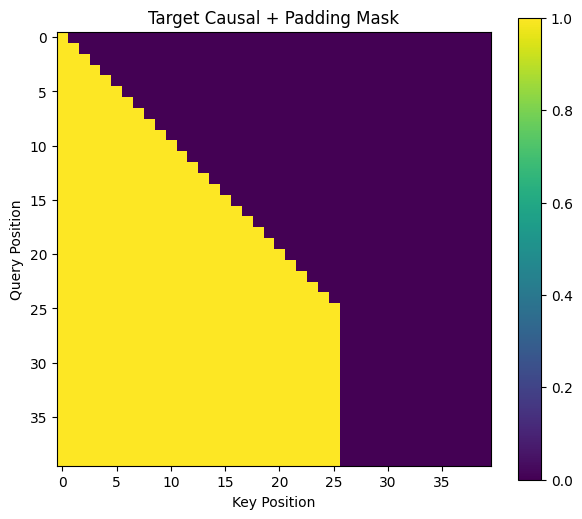

In [138]:
mask_image = (
    combined_tgt_mask[
        0,
        0
    ]
    .detach()
    .cpu()
)

plt.figure(figsize=(7, 6))

plt.imshow(mask_image)

plt.xlabel("Key Position")
plt.ylabel("Query Position")

plt.title(
    "Target Causal + Padding Mask"
)

plt.colorbar()

plt.show()

# **21. Create DataLoaders**

*Build validation and test datasets*

In [139]:
validation_data = TranslationDataset(
    validation_dataset,

    english_tokenizer,
    german_tokenizer,

    MAX_LEN,

    SRC_BOS_ID,
    SRC_EOS_ID,
    SRC_PAD_ID,

    TGT_BOS_ID,
    TGT_EOS_ID,
    TGT_PAD_ID
)


test_data = TranslationDataset(
    test_dataset,

    english_tokenizer,
    german_tokenizer,

    MAX_LEN,

    SRC_BOS_ID,
    SRC_EOS_ID,
    SRC_PAD_ID,

    TGT_BOS_ID,
    TGT_EOS_ID,
    TGT_PAD_ID
)

print(
    "Train:",
    len(train_data)
)

print(
    "Validation:",
    len(validation_data)
)

print(
    "Test:",
    len(test_data)
)

Train: 18000
Validation: 1000
Test: 1000


In [140]:
BATCH_SIZE = 32

print(
    "Batch size:",
    BATCH_SIZE
)

Batch size: 32


*Create DataLoaders*

In [141]:
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(validation_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 563
Validation batches: 32
Test batches: 32


In [142]:
batch = next(
    iter(train_loader)
)

print(
    "Encoder input:",
    batch["encoder_input"].shape
)

print(
    "Decoder input:",
    batch["decoder_input"].shape
)

print(
    "Labels:",
    batch["labels"].shape
)

Encoder input: torch.Size([32, 40])
Decoder input: torch.Size([32, 40])
Labels: torch.Size([32, 40])


*Move batch to GPU*

In [143]:
src_batch = batch[
    "encoder_input"
].to(device)

tgt_batch = batch[
    "decoder_input"
].to(device)

label_batch = batch[
    "labels"
].to(device)

print(
    src_batch.device
)

print(
    tgt_batch.device
)

print(
    label_batch.device
)

cuda:0
cuda:0
cuda:0


*Build masks for the whole batch*

In [144]:
src_mask = create_padding_mask(
    src_batch,
    SRC_PAD_ID
)

tgt_mask = create_target_mask(
    tgt_batch,
    TGT_PAD_ID
)

print(
    "Source mask:",
    src_mask.shape
)

print(
    "Target mask:",
    tgt_mask.shape
)

Source mask: torch.Size([32, 1, 1, 40])
Target mask: torch.Size([32, 1, 40, 40])


# **22. Build the REAL Training Model**

*Define scaled reproduction configuration*

In [145]:
SRC_VOCAB_SIZE = (
    english_tokenizer.get_vocab_size()
)

TGT_VOCAB_SIZE = (
    german_tokenizer.get_vocab_size()
)

D_MODEL = 128

NUM_HEADS = 4

D_FF = 512

NUM_ENCODER_LAYERS = 3

NUM_DECODER_LAYERS = 3

DROPOUT = 0.1


print(
    "Source vocab:",
    SRC_VOCAB_SIZE
)

print(
    "Target vocab:",
    TGT_VOCAB_SIZE
)

print(
    "d_model:",
    D_MODEL
)

print(
    "Heads:",
    NUM_HEADS
)

print(
    "d_k:",
    D_MODEL // NUM_HEADS
)

Source vocab: 12009
Target vocab: 15834
d_model: 128
Heads: 4
d_k: 32


*Instantiate the real model*

In [146]:
model = Transformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,

    d_model=D_MODEL,
    num_heads=NUM_HEADS,

    d_ff=D_FF,

    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,

    max_len=MAX_LEN,

    dropout=DROPOUT
).to(device)

In [147]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Total parameters: {total_params:,}"
)

Total parameters: 6,995,034


In [148]:
model.eval()

with torch.no_grad():

    (
        batch_logits,
        _,
        _,
        _
    ) = model(
        src_batch,
        tgt_batch,
        src_mask=src_mask,
        tgt_mask=tgt_mask
    )

print(
    "Output logits:",
    batch_logits.shape
)

Output logits: torch.Size([32, 40, 15834])


*Create proper training loss*

In [149]:
criterion = nn.CrossEntropyLoss(
    ignore_index=TGT_PAD_ID
)

print(criterion)

CrossEntropyLoss()


*Compute real batch loss*

In [150]:
real_loss = criterion(
    batch_logits.reshape(
        -1,
        TGT_VOCAB_SIZE
    ),

    label_batch.reshape(-1)
)

print(
    "Real batch loss:",
    real_loss.item()
)

Real batch loss: 9.795021057128906


*One real gradient test*

In [151]:
model.train()

model.zero_grad()

(
    training_logits,
    _,
    _,
    _
) = model(
    src_batch,
    tgt_batch,
    src_mask=src_mask,
    tgt_mask=tgt_mask
)

loss = criterion(
    training_logits.reshape(
        -1,
        TGT_VOCAB_SIZE
    ),

    label_batch.reshape(-1)
)

loss.backward()

print(
    "Loss:",
    loss.item()
)

print(
    "Encoder embedding gradient:",
    model.encoder
    .embedding
    .weight
    .grad is not None
)

print(
    "Decoder embedding gradient:",
    model.decoder
    .embedding
    .weight
    .grad is not None
)

print(
    "Output gradient:",
    model.output_projection
    .weight
    .grad is not None
)

Loss: 9.793659210205078
Encoder embedding gradient: True
Decoder embedding gradient: True
Output gradient: True


# **23.  Optimizer from the paper**

*Clear old GPU memory*

In [152]:
import gc

gc.collect()

torch.cuda.empty_cache()

print("GPU cache cleared")

GPU cache cleared


*Create the Adam optimizer*

In [153]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0,
    betas=(0.9, 0.98),
    eps=1e-9
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.98)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-09
    foreach: None
    fused: None
    lr: 0.0
    maximize: False
    weight_decay: 0
)


*Implement the Transformer learning-rate formula*

In [154]:
def transformer_learning_rate(
    step,
    d_model,
    warmup_steps
):

    step = max(step, 1)

    return (
        d_model ** (-0.5)
        *
        min(
            step ** (-0.5),
            step * (
                warmup_steps ** (-1.5)
            )
        )
    )

In [155]:
WARMUP_STEPS = 4000

print(
    "Warmup steps:",
    WARMUP_STEPS
)

Warmup steps: 4000


In [156]:
for step in [
    1,
    100,
    500,
    1000,
    2000,
    4000,
    8000
]:

    lr = transformer_learning_rate(
        step,
        D_MODEL,
        WARMUP_STEPS
    )

    print(
        f"Step {step:5d} -> LR {lr:.8f}"
    )

Step     1 -> LR 0.00000035
Step   100 -> LR 0.00003494
Step   500 -> LR 0.00017469
Step  1000 -> LR 0.00034939
Step  2000 -> LR 0.00069877
Step  4000 -> LR 0.00139754
Step  8000 -> LR 0.00098821


*learning-rate schedule*

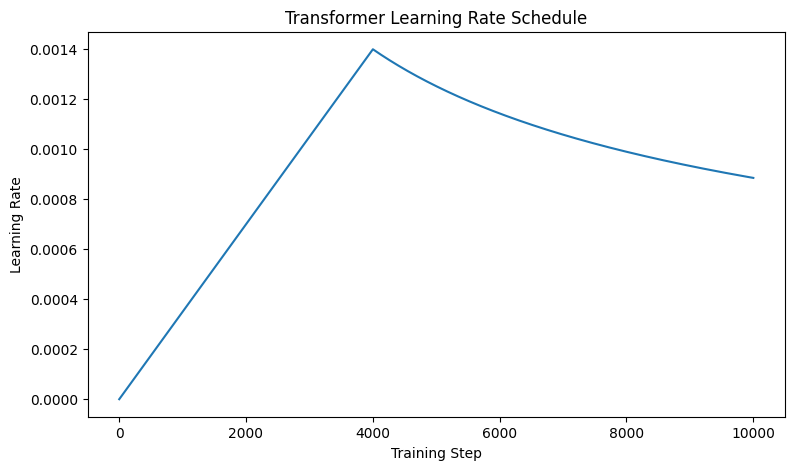

In [157]:
lr_steps = list(
    range(1, 10001)
)

lr_values = [
    transformer_learning_rate(
        step,
        D_MODEL,
        WARMUP_STEPS
    )
    for step in lr_steps
]

plt.figure(figsize=(9, 5))

plt.plot(
    lr_steps,
    lr_values
)

plt.xlabel("Training Step")
plt.ylabel("Learning Rate")

plt.title(
    "Transformer Learning Rate Schedule"
)

plt.show()

*function that updates optimizer LR*

In [158]:
def update_learning_rate(
    optimizer,
    step,
    d_model,
    warmup_steps
):

    lr = transformer_learning_rate(
        step,
        d_model,
        warmup_steps
    )

    for param_group in optimizer.param_groups:
        param_group["lr"] = lr

    return lr

# **24. Label Smoothing**

*Paper-style loss*

In [159]:
criterion = nn.CrossEntropyLoss(
    ignore_index=TGT_PAD_ID,
    label_smoothing=0.1
)

print(criterion)

CrossEntropyLoss()


# **25. Build one training step**

In [160]:
model.train()

batch = next(
    iter(train_loader)
)

src = batch[
    "encoder_input"
].to(device)

tgt = batch[
    "decoder_input"
].to(device)

labels = batch[
    "labels"
].to(device)


src_mask = create_padding_mask(
    src,
    SRC_PAD_ID
)

tgt_mask = create_target_mask(
    tgt,
    TGT_PAD_ID
)


optimizer.zero_grad()


logits, _, _, _ = model(
    src,
    tgt,
    src_mask=src_mask,
    tgt_mask=tgt_mask
)


loss = criterion(
    logits.reshape(
        -1,
        TGT_VOCAB_SIZE
    ),
    labels.reshape(-1)
)


current_lr = update_learning_rate(
    optimizer,
    step=1,
    d_model=D_MODEL,
    warmup_steps=WARMUP_STEPS
)


loss.backward()


torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0
)


optimizer.step()


print(
    "Loss:",
    loss.item()
)

print(
    "Learning rate:",
    current_lr
)

Loss: 9.832963943481445
Learning rate: 3.493856214843422e-07


# **26. Full Training Epoch Function**

In [161]:
from tqdm.auto import tqdm

print("tqdm ready")

tqdm ready


In [162]:
def train_one_epoch(
    model,
    data_loader,
    optimizer,
    criterion,
    device,
    global_step,
    d_model,
    warmup_steps
):

    model.train()

    total_loss = 0.0

    progress_bar = tqdm(
        data_loader,
        desc="Training"
    )


    for batch in progress_bar:

        # --------------------
        # Move batch to GPU
        # --------------------

        src = batch[
            "encoder_input"
        ].to(device)

        tgt = batch[
            "decoder_input"
        ].to(device)

        labels = batch[
            "labels"
        ].to(device)


        # --------------------
        # Create masks
        # --------------------

        src_mask = create_padding_mask(
            src,
            SRC_PAD_ID
        )

        tgt_mask = create_target_mask(
            tgt,
            TGT_PAD_ID
        )


        # --------------------
        # Reset gradients
        # --------------------

        optimizer.zero_grad()


        # --------------------
        # Forward
        # --------------------

        logits, _, _, _ = model(
            src,
            tgt,
            src_mask=src_mask,
            tgt_mask=tgt_mask
        )


        # --------------------
        # Loss
        # --------------------

        loss = criterion(
            logits.reshape(
                -1,
                TGT_VOCAB_SIZE
            ),
            labels.reshape(-1)
        )


        # --------------------
        # Learning rate
        # --------------------

        global_step += 1

        current_lr = update_learning_rate(
            optimizer,
            global_step,
            d_model,
            warmup_steps
        )


        # --------------------
        # Backward
        # --------------------

        loss.backward()


        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # --------------------
        # Update parameters
        # --------------------

        optimizer.step()


        total_loss += loss.item()


        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{current_lr:.7f}"
        )


    average_loss = (
        total_loss
        /
        len(data_loader)
    )


    return (
        average_loss,
        global_step
    )

# **27. Validation Function**

In [163]:
def validate(
    model,
    data_loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0


    with torch.no_grad():

        progress_bar = tqdm(
            data_loader,
            desc="Validation"
        )


        for batch in progress_bar:

            src = batch[
                "encoder_input"
            ].to(device)

            tgt = batch[
                "decoder_input"
            ].to(device)

            labels = batch[
                "labels"
            ].to(device)


            src_mask = create_padding_mask(
                src,
                SRC_PAD_ID
            )

            tgt_mask = create_target_mask(
                tgt,
                TGT_PAD_ID
            )


            logits, _, _, _ = model(
                src,
                tgt,
                src_mask=src_mask,
                tgt_mask=tgt_mask
            )


            loss = criterion(
                logits.reshape(
                    -1,
                    TGT_VOCAB_SIZE
                ),
                labels.reshape(-1)
            )


            total_loss += loss.item()


            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )


    average_loss = (
        total_loss
        /
        len(data_loader)
    )


    return average_loss

# **28. First DEBUG Training Run**

*Create tiny debug loader*

In [164]:
debug_size = min(
    512,
    len(train_data)
)

debug_dataset = torch.utils.data.Subset(
    train_data,
    range(debug_size)
)

debug_loader = DataLoader(
    debug_dataset,
    batch_size=32,
    shuffle=True
)

print(
    "Debug examples:",
    len(debug_dataset)
)

print(
    "Debug batches:",
    len(debug_loader)
)

Debug examples: 512
Debug batches: 16


*Reset model before debug test*

In [165]:
debug_model = Transformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,

    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,

    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,

    max_len=MAX_LEN,
    dropout=DROPOUT
).to(device)


debug_optimizer = torch.optim.Adam(
    debug_model.parameters(),
    lr=0.0,
    betas=(0.9, 0.98),
    eps=1e-9
)


debug_global_step = 0

In [166]:
from tqdm.auto import tqdm

def train_one_epoch(
    model,
    data_loader,
    optimizer,
    criterion,
    device,
    global_step,
    d_model,
    warmup_steps
):

    model.train()
    total_loss = 0.0

    progress_bar = tqdm(
        data_loader,
        desc="Training"
    )

    for batch in progress_bar:

        src = batch[
            "encoder_input"
        ].to(device)

        tgt = batch[
            "decoder_input"
        ].to(device)

        labels = batch[
            "labels"
        ].to(device)

        src_mask = create_padding_mask(
            src,
            SRC_PAD_ID
        )

        tgt_mask = create_target_mask(
            tgt,
            TGT_PAD_ID
        )

        optimizer.zero_grad()

        logits, _, _, _ = model(
            src,
            tgt,
            src_mask=src_mask,
            tgt_mask=tgt_mask
        )

        loss = criterion(
            logits.reshape(
                -1,
                TGT_VOCAB_SIZE
            ),
            labels.reshape(-1)
        )

        global_step += 1

        current_lr = update_learning_rate(
            optimizer,
            global_step,
            d_model,
            warmup_steps
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{current_lr:.7f}"
        )

    average_loss = (
        total_loss / len(data_loader)
    )

    return average_loss, global_step

*Train DEBUG model for one epoch*

In [167]:
debug_loss, debug_global_step = (
    train_one_epoch(
        debug_model,
        debug_loader,
        debug_optimizer,
        criterion,
        device,
        debug_global_step,
        D_MODEL,
        WARMUP_STEPS
    )
)

print(
    "Debug training loss:",
    debug_loss
)

Training:   0%|          | 0/16 [00:00<?, ?it/s]

Debug training loss: 9.837431073188782


In [168]:
for epoch in range(1, 4):

    debug_loss, debug_global_step = (
        train_one_epoch(
            debug_model,
            debug_loader,
            debug_optimizer,
            criterion,
            device,
            debug_global_step,
            D_MODEL,
            WARMUP_STEPS
        )
    )

    print(
        f"Debug epoch {epoch}: "
        f"{debug_loss:.4f}"
    )

Training:   0%|          | 0/16 [00:00<?, ?it/s]

Debug epoch 1: 9.7839


Training:   0%|          | 0/16 [00:00<?, ?it/s]

Debug epoch 2: 9.6847


Training:   0%|          | 0/16 [00:00<?, ?it/s]

Debug epoch 3: 9.5351


# **29. Start the Actual Training Run**

*Delete debug model*

In [169]:
del debug_model
del debug_optimizer

gc.collect()

torch.cuda.empty_cache()

print(
    "Debug model removed."
)

Debug model removed.


*Fresh real model*

In [170]:
model = Transformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,

    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,

    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,

    max_len=MAX_LEN,
    dropout=DROPOUT
).to(device)

In [171]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0,
    betas=(0.9, 0.98),
    eps=1e-9
)

global_step = 0

*Create result storage*

In [172]:
train_losses = []
validation_losses = []

learning_rate_history = []

best_validation_loss = float(
    "inf"
)

*Create checkpoint directory*

In [173]:
import os

CHECKPOINT_DIR = (
    "/content/transformer_checkpoints"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

print(
    CHECKPOINT_DIR
)

/content/transformer_checkpoints


# **30. Train the Transformer**

In [174]:
NUM_EPOCHS = 2

for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    print(
        f"\n===== EPOCH {epoch}/{NUM_EPOCHS} ====="
    )


    # TRAINING
    train_loss, global_step = (
        train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            global_step,
            D_MODEL,
            WARMUP_STEPS
        )
    )


    # VALIDATION
    val_loss = validate(
        model,
        validation_loader,
        criterion,
        device
    )


    train_losses.append(
        train_loss
    )

    validation_losses.append(
        val_loss
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )


    # ----------------------------
    # Save best checkpoint
    # ----------------------------

    if val_loss < best_validation_loss:

        best_validation_loss = (
            val_loss
        )

        checkpoint_path = os.path.join(
            CHECKPOINT_DIR,
            "best_transformer.pt"
        )


        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "global_step":
                    global_step,

                "train_loss":
                    train_loss,

                "validation_loss":
                    val_loss,

                "config": {
                    "d_model": D_MODEL,
                    "num_heads": NUM_HEADS,
                    "d_ff": D_FF,
                    "encoder_layers":
                        NUM_ENCODER_LAYERS,
                    "decoder_layers":
                        NUM_DECODER_LAYERS,
                    "max_len": MAX_LEN,
                    "dropout": DROPOUT
                }
            },

            checkpoint_path
        )


        print(
            "✓ Best model checkpoint saved!"
        )


===== EPOCH 1/2 =====


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 7.8880
Validation Loss: 6.4622
✓ Best model checkpoint saved!

===== EPOCH 2/2 =====


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 6.3524
Validation Loss: 5.9581
✓ Best model checkpoint saved!


*first real training curve*

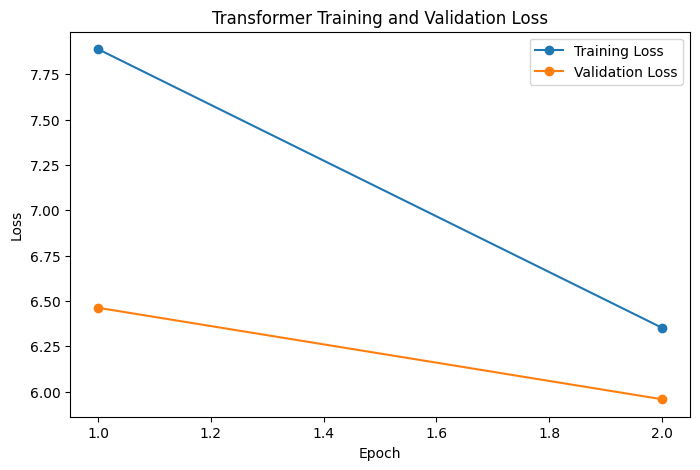

In [175]:
epochs = range(
    1,
    len(train_losses) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Transformer Training and Validation Loss"
)

plt.legend()

plt.show()

*Confirm checkpoint exists*

In [176]:
checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "best_transformer.pt"
)

print(
    "Checkpoint exists:",
    os.path.exists(
        checkpoint_path
    )
)

print(
    "Checkpoint size MB:",
    os.path.getsize(
        checkpoint_path
    ) / (1024 ** 2)
)

Checkpoint exists: True
Checkpoint size MB: 80.24828624725342


# **31. Autoregressive Translation**

*Load best model*

In [177]:
checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "best_transformer.pt"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print(
    "Loaded checkpoint from epoch:",
    checkpoint["epoch"]
)

print(
    "Validation loss:",
    checkpoint["validation_loss"]
)

Loaded checkpoint from epoch: 2
Validation loss: 5.958086133003235


*Create English input function*

In [178]:
def prepare_source_sentence(
    sentence,
    tokenizer,
    max_len,
    bos_id,
    eos_id,
    pad_id,
    device
):

    token_ids = (
        tokenizer
        .encode(sentence)
        .ids
    )

    token_ids = token_ids[
        :max_len - 2
    ]

    token_ids = (
        [bos_id]
        + token_ids
        + [eos_id]
    )

    padding_length = (
        max_len - len(token_ids)
    )

    token_ids = (
        token_ids
        + [pad_id] * padding_length
    )

    tensor = torch.tensor(
        [token_ids],
        dtype=torch.long,
        device=device
    )

    return tensor

*Test source preparation*

In [179]:
test_sentence = "I love books."

prepared_source = prepare_source_sentence(
    test_sentence,
    english_tokenizer,
    MAX_LEN,
    SRC_BOS_ID,
    SRC_EOS_ID,
    SRC_PAD_ID,
    device
)

print(
    "Shape:",
    prepared_source.shape
)

print(
    prepared_source
)

Shape: torch.Size([1, 40])
tensor([[  1,  12, 178, 988,   6,   2,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]],
       device='cuda:0')


# **32. Greedy Decoding**

*Greedy translation function*

In [180]:
def greedy_translate(
    model,
    sentence,
    src_tokenizer,
    tgt_tokenizer,
    max_len,
    device
):

    model.eval()

    # --------------------------------
    # Prepare English source sentence
    # --------------------------------

    src = prepare_source_sentence(
        sentence,
        src_tokenizer,
        max_len,
        SRC_BOS_ID,
        SRC_EOS_ID,
        SRC_PAD_ID,
        device
    )

    src_mask = create_padding_mask(
        src,
        SRC_PAD_ID
    )


    # --------------------------------
    # Start German decoder with <bos>
    # --------------------------------

    generated = torch.tensor(
        [[TGT_BOS_ID]],
        dtype=torch.long,
        device=device
    )


    with torch.no_grad():

        for _ in range(
            max_len - 1
        ):

            tgt_mask = create_target_mask(
                generated,
                TGT_PAD_ID
            )


            logits, _, _, _ = model(
                src,
                generated,
                src_mask=src_mask,
                tgt_mask=tgt_mask
            )


            # Prediction for latest position
            next_token_logits = (
                logits[:, -1, :]
            )


            next_token = torch.argmax(
                next_token_logits,
                dim=-1
            ).unsqueeze(1)


            generated = torch.cat(
                [
                    generated,
                    next_token
                ],
                dim=1
            )


            # Stop when EOS generated
            if (
                next_token.item()
                == TGT_EOS_ID
            ):
                break


    generated_ids = (
        generated[0]
        .detach()
        .cpu()
        .tolist()
    )


    # Remove BOS
    generated_ids = (
        generated_ids[1:]
    )


    # Remove EOS if present
    if TGT_EOS_ID in generated_ids:

        eos_position = (
            generated_ids.index(
                TGT_EOS_ID
            )
        )

        generated_ids = (
            generated_ids[
                :eos_position
            ]
        )


    translated_text = (
        tgt_tokenizer.decode(
            generated_ids
        )
    )


    return (
        translated_text,
        generated_ids
    )

*FIRST REAL TRANSLATION*

In [181]:
sentence = "I love books."

translation, token_ids = greedy_translate(
    model,
    sentence,
    english_tokenizer,
    german_tokenizer,
    MAX_LEN,
    device
)

print(
    "English:"
)

print(
    sentence
)

print()

print(
    "Transformer German:"
)

print(
    translation
)

print()

print(
    "Generated IDs:"
)

print(
    token_ids
)

English:
I love books.

Transformer German:
Ich habe ich mich .

Generated IDs:
[41, 78, 16, 49, 5]


In [182]:
test_sentences = [
    "I love books.",
    "The man is happy.",
    "She is my friend.",
    "The house is beautiful.",
    "I am tired.",
    "He opened the door.",
    "Where are you?"
]


for sentence in test_sentences:

    translation, _ = greedy_translate(
        model,
        sentence,
        english_tokenizer,
        german_tokenizer,
        MAX_LEN,
        device
    )

    print(
        "EN:",
        sentence
    )

    print(
        "DE:",
        translation
    )

    print(
        "-" * 50
    )

EN: I love books.
DE: Ich habe ich mich .
--------------------------------------------------
EN: The man is happy.
DE: Die ist , die .
--------------------------------------------------
EN: She is my friend.
DE: Sie ist , daß ich ist .
--------------------------------------------------
EN: The house is beautiful.
DE: Die ist , daß es ist .
--------------------------------------------------
EN: I am tired.
DE: Ich habe ich .
--------------------------------------------------
EN: He opened the door.
DE: Er war die .
--------------------------------------------------
EN: Where are you?
DE: Sie Sie ?
--------------------------------------------------


# **33. Test Against Real Held-Out Examples**

In [183]:
for i in range(5):

    example = test_dataset[i]

    english_sentence = (
        example[
            "translation"
        ]["en"]
    )

    real_german = (
        example[
            "translation"
        ]["de"]
    )

    predicted_german, _ = (
        greedy_translate(
            model,
            english_sentence,
            english_tokenizer,
            german_tokenizer,
            MAX_LEN,
            device
        )
    )


    print(
        "ENGLISH:"
    )

    print(
        english_sentence
    )


    print(
        "\nREFERENCE:"
    )

    print(
        real_german
    )


    print(
        "\nMODEL:"
    )

    print(
        predicted_german
    )

    print(
        "\n" + "=" * 70 + "\n"
    )

ENGLISH:
She then declaimed the little piece with an attention to punctuation and emphasis, a flexibility of voice and an appropriateness of gesture, very unusual indeed at her age, and which proved she had been carefully trained.

REFERENCE:
Nun deklamierte sie das kleine Stück mit einer Achtsamkeit auf die Interpunktion und Betonung, einer Biegsamkeit der Stimme und einer Zartheit der Bewegungen, welche in ihren Jahren allerdings ungewöhnlich waren und deutlich bewiesen, daß sie sorgsam trainiert worden war.

MODEL:
Die und , und sie sich mit dem und und und und und und und und und , und , und , und


ENGLISH:
They had small means.

REFERENCE:
Vermögen war nur wenig vorhanden.

MODEL:
Sie war die .


ENGLISH:
Oh, please!" "All right if you say it, Huck, but you ought to have the credit of what you did."

REFERENCE:
,,Ist schon gut, Huck, wenn du's wünschst, aber du sollst doch den Lohn für das haben, was du da getan hast!"

MODEL:
» Sie Sie Sie , daß Sie du nicht , daß Sie du , daß S

# **34. Measure Test Loss**

In [184]:
test_loss = validate(
    model,
    test_loader,
    criterion,
    device
)

print(
    f"Final Test Loss: {test_loss:.4f}"
)

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Final Test Loss: 5.9594


##**35. Save Sample Predictions**

In [185]:
sample_results = []

for i in range(
    min(20, len(test_dataset))
):

    example = test_dataset[i]

    source = (
        example[
            "translation"
        ]["en"]
    )

    reference = (
        example[
            "translation"
        ]["de"]
    )

    prediction, _ = greedy_translate(
        model,
        source,
        english_tokenizer,
        german_tokenizer,
        MAX_LEN,
        device
    )

    sample_results.append(
        {
            "source": source,
            "reference": reference,
            "prediction": prediction
        }
    )


print(
    "Saved predictions:",
    len(sample_results)
)

Saved predictions: 20


In [186]:
import pandas as pd

results_df = pd.DataFrame(
    sample_results
)

results_df.head(10)

,source,reference,prediction
0,She then declaimed the little piece with an at...,Nun deklamierte sie das kleine Stück mit einer...,"Die und , und sie sich mit dem und und und und..."
1,They had small means.,Vermögen war nur wenig vorhanden.,Sie war die .
2,"Oh, please!"" ""All right if you say it, Huck, b...",",,Ist schon gut, Huck, wenn du's wünschst, abe...","» Sie Sie Sie , daß Sie du nicht , daß Sie du ..."
3,"Emma, at home once more, first took pleasure i...",Bei aller Schwärmerei war sie doch eine Versta...,"Sie war die und die , die , und die , die , un..."
4,"""Good-night, then, sir,"" said I, departing.","»Gute Nacht denn, Sir,« sagte ich im Begriff f...","» Ich habe , » Ich habe , » ich mich , » ich m..."
5,"Under this pretence he took Ramiro, and one mo...","Er ergriff die erste Veranlassung, ihn eines T...","Die und , die und er sich mit dem und und und ..."
6,What a lot of them there are!' said she after ...,Welch eine Menge!« wiederholte sie nach kurzem...,"» Das ist sie , daß sie , daß sie , daß sie , ..."
7,'Love those that hate you...' whispered Dolly ...,"»Liebet, die euch hassen ...«, flüsterte Darja...","» Sie Sie , daß Sie , daß Sie nicht ."
8,"I got up, I went to the door; I came back agai...",Ich stand auf; ich ging an die Thür; ich kam w...,"Ich habe ich mich , ich ich mich , daß ich mic..."
9,"If that law is ignored when fixing a salary, a...",Wenn aber ein Gehaltssatz von diesem Gesetze a...,"Ich habe , daß ich mich , daß ich mich , daß i..."


# **36. BLEU Evaluation**

In [187]:
!pip install -q sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 14.5 MB/s eta 0:00:00


In [188]:
import sacrebleu

print("SacreBLEU ready!")

SacreBLEU ready!


*Generate predictions for the test set*

In [189]:
bleu_predictions = []
bleu_references = []

NUM_BLEU_EXAMPLES = min(
    200,
    len(test_dataset)
)

for i in tqdm(
    range(NUM_BLEU_EXAMPLES),
    desc="Generating translations"
):

    example = test_dataset[i]

    source = example[
        "translation"
    ]["en"]

    reference = example[
        "translation"
    ]["de"]

    prediction, _ = greedy_translate(
        model,
        source,
        english_tokenizer,
        german_tokenizer,
        MAX_LEN,
        device
    )

    bleu_predictions.append(
        prediction
    )

    bleu_references.append(
        reference
    )

print(
    "Predictions:",
    len(bleu_predictions)
)

print(
    "References:",
    len(bleu_references)
)

Generating translations:   0%|          | 0/200 [00:00<?, ?it/s]

Predictions: 200
References: 200


*Compute corpus BLEU*

In [190]:
bleu_result = sacrebleu.corpus_bleu(
    bleu_predictions,
    [
        bleu_references
    ]
)

print(
    bleu_result
)

print(
    "\nBLEU score:",
    bleu_result.score
)

BLEU = 0.51 28.8/3.2/0.3/0.0 (BP = 0.610 ratio = 0.669 hyp_len = 3707 ref_len = 5537)

BLEU score: 0.512392286142646


*Save BLEU score*

In [191]:
baseline_bleu = bleu_result.score

print(
    f"Baseline BLEU: {baseline_bleu:.2f}"
)

Baseline BLEU: 0.51


# **37. Inspect Translation Quality**

In [192]:
for i in range(
    min(10, NUM_BLEU_EXAMPLES)
):

    print(
        f"Example {i + 1}"
    )

    print(
        "SOURCE:"
    )
    print(
        test_dataset[i][
            "translation"
        ]["en"]
    )

    print(
        "\nREFERENCE:"
    )
    print(
        bleu_references[i]
    )

    print(
        "\nPREDICTION:"
    )
    print(
        bleu_predictions[i]
    )

    print(
        "\n" + "-" * 70
    )

Example 1
SOURCE:
She then declaimed the little piece with an attention to punctuation and emphasis, a flexibility of voice and an appropriateness of gesture, very unusual indeed at her age, and which proved she had been carefully trained.

REFERENCE:
Nun deklamierte sie das kleine Stück mit einer Achtsamkeit auf die Interpunktion und Betonung, einer Biegsamkeit der Stimme und einer Zartheit der Bewegungen, welche in ihren Jahren allerdings ungewöhnlich waren und deutlich bewiesen, daß sie sorgsam trainiert worden war.

PREDICTION:
Die und , und sie sich mit dem und und und und und und und und und , und , und , und

----------------------------------------------------------------------
Example 2
SOURCE:
They had small means.

REFERENCE:
Vermögen war nur wenig vorhanden.

PREDICTION:
Sie war die .

----------------------------------------------------------------------
Example 3
SOURCE:
Oh, please!" "All right if you say it, Huck, but you ought to have the credit of what you did."

REFER

# **38. Visualize Encoder Attention**

In [193]:
attention_example = test_dataset[0]

attention_source_text = (
    attention_example[
        "translation"
    ]["en"]
)

print(
    attention_source_text
)

She then declaimed the little piece with an attention to punctuation and emphasis, a flexibility of voice and an appropriateness of gesture, very unusual indeed at her age, and which proved she had been carefully trained.


*Convert source to tokens*

In [194]:
source_encoding = english_tokenizer.encode(
    attention_source_text
)

source_words = source_encoding.tokens[
    :MAX_LEN - 2
]

source_words = (
    [BOS_TOKEN]
    + source_words
    + [EOS_TOKEN]
)

print(
    source_words
)

['<bos>', 'She', 'then', 'declaimed', 'the', 'little', 'piece', 'with', 'an', 'attention', 'to', '<unk>', 'and', 'emphasis', ',', 'a', '<unk>', 'of', 'voice', 'and', 'an', '<unk>', 'of', 'gesture', ',', 'very', 'unusual', 'indeed', 'at', 'her', 'age', ',', 'and', 'which', 'proved', 'she', 'had', 'been', 'carefully', '<eos>']


*Prepare tensor*

In [195]:
attention_src = prepare_source_sentence(
    attention_source_text,
    english_tokenizer,
    MAX_LEN,
    SRC_BOS_ID,
    SRC_EOS_ID,
    SRC_PAD_ID,
    device
)

attention_src_mask = create_padding_mask(
    attention_src,
    SRC_PAD_ID
)

print(
    attention_src.shape
)

torch.Size([1, 40])


*Run encoder and collect attention maps*

In [196]:
model.eval()

with torch.no_grad():

    (
        encoder_output,
        encoder_attention_maps
    ) = model.encoder(
        attention_src,
        attention_src_mask
    )

print(
    "Encoder layers:",
    len(encoder_attention_maps)
)

print(
    "Attention map shape:",
    encoder_attention_maps[0].shape
)

Encoder layers: 3
Attention map shape: torch.Size([1, 4, 40, 40])


# **39. Plot One Attention Head**

In [197]:
# Recreate source_words

attention_example = test_dataset[0]

attention_source_text = (
    attention_example["translation"]["en"]
)

source_encoding = english_tokenizer.encode(
    attention_source_text
)

source_words = source_encoding.tokens[
    :MAX_LEN - 2
]

source_words = (
    [BOS_TOKEN]
    + source_words
    + [EOS_TOKEN]
)

actual_length = len(source_words)

print("Source sentence:")
print(attention_source_text)

print("\nSource words:")
print(source_words)

print("\nActual length:")
print(actual_length)

Source sentence:
She then declaimed the little piece with an attention to punctuation and emphasis, a flexibility of voice and an appropriateness of gesture, very unusual indeed at her age, and which proved she had been carefully trained.

Source words:
['<bos>', 'She', 'then', 'declaimed', 'the', 'little', 'piece', 'with', 'an', 'attention', 'to', '<unk>', 'and', 'emphasis', ',', 'a', '<unk>', 'of', 'voice', 'and', 'an', '<unk>', 'of', 'gesture', ',', 'very', 'unusual', 'indeed', 'at', 'her', 'age', ',', 'and', 'which', 'proved', 'she', 'had', 'been', 'carefully', '<eos>']

Actual length:
40


In [198]:
print("source_words exists:", source_words)
print("actual_length:", actual_length)

source_words exists: ['<bos>', 'She', 'then', 'declaimed', 'the', 'little', 'piece', 'with', 'an', 'attention', 'to', '<unk>', 'and', 'emphasis', ',', 'a', '<unk>', 'of', 'voice', 'and', 'an', '<unk>', 'of', 'gesture', ',', 'very', 'unusual', 'indeed', 'at', 'her', 'age', ',', 'and', 'which', 'proved', 'she', 'had', 'been', 'carefully', '<eos>']
actual_length: 40


In [199]:
actual_length = len(
    source_words
)

attention_matrix = (
    encoder_attention_maps[0][
        0,
        0,
        :actual_length,
        :actual_length
    ]
    .detach()
    .cpu()
)

print(
    attention_matrix.shape
)

torch.Size([40, 40])


*185. Attention heatmap*

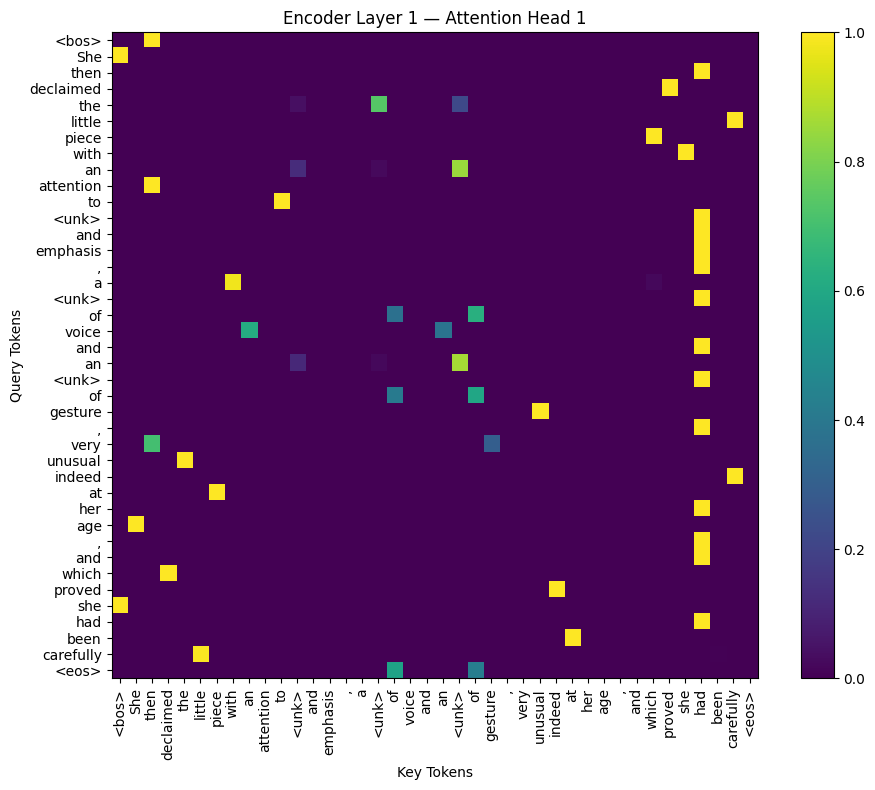

In [200]:
plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    attention_matrix
)

plt.xticks(
    range(actual_length),
    source_words,
    rotation=90
)

plt.yticks(
    range(actual_length),
    source_words
)

plt.xlabel(
    "Key Tokens"
)

plt.ylabel(
    "Query Tokens"
)

plt.title(
    "Encoder Layer 1 — Attention Head 1"
)

plt.colorbar()

plt.tight_layout()

plt.show()

# **40. Compare All Attention Heads**

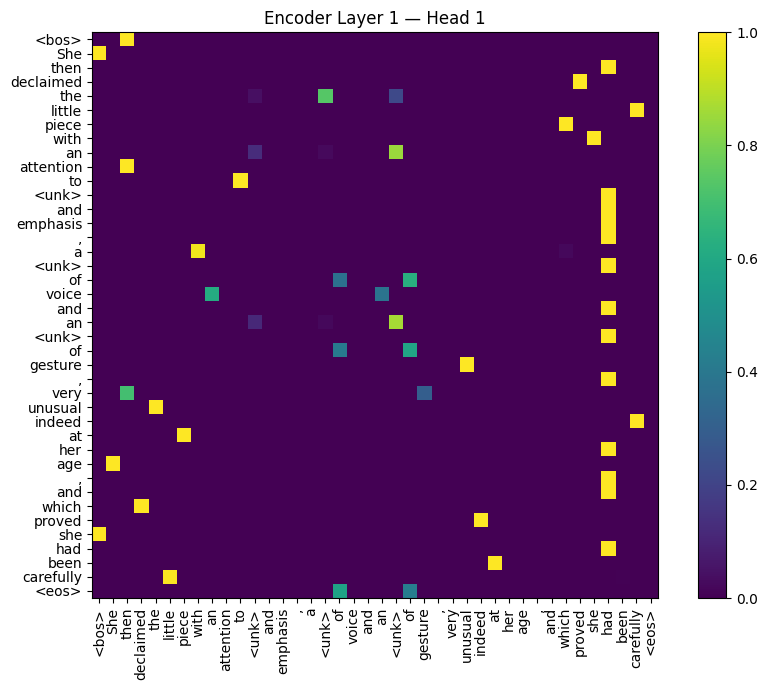

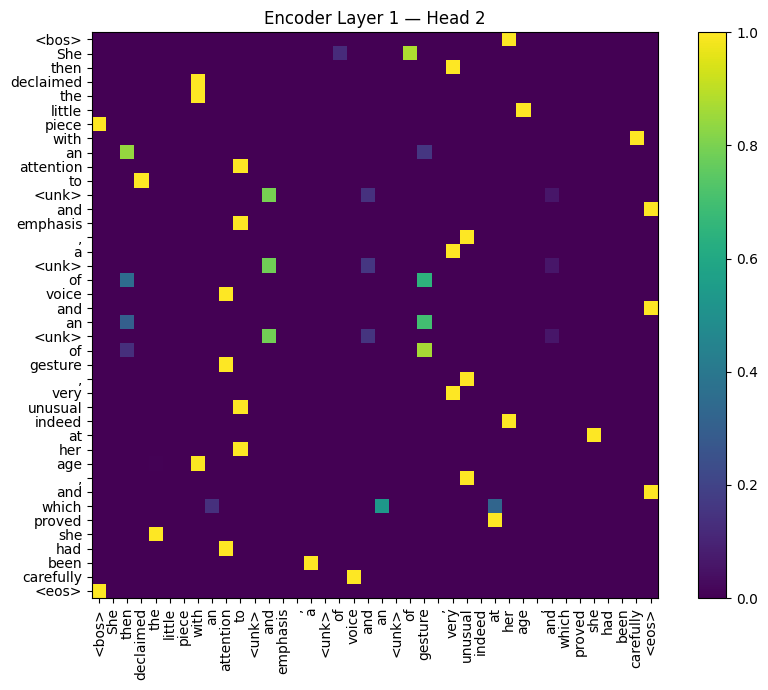

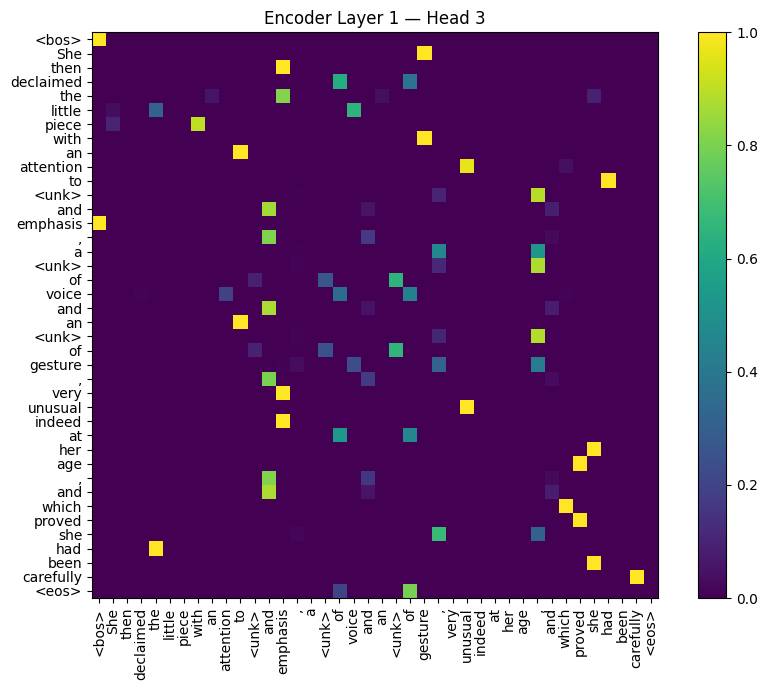

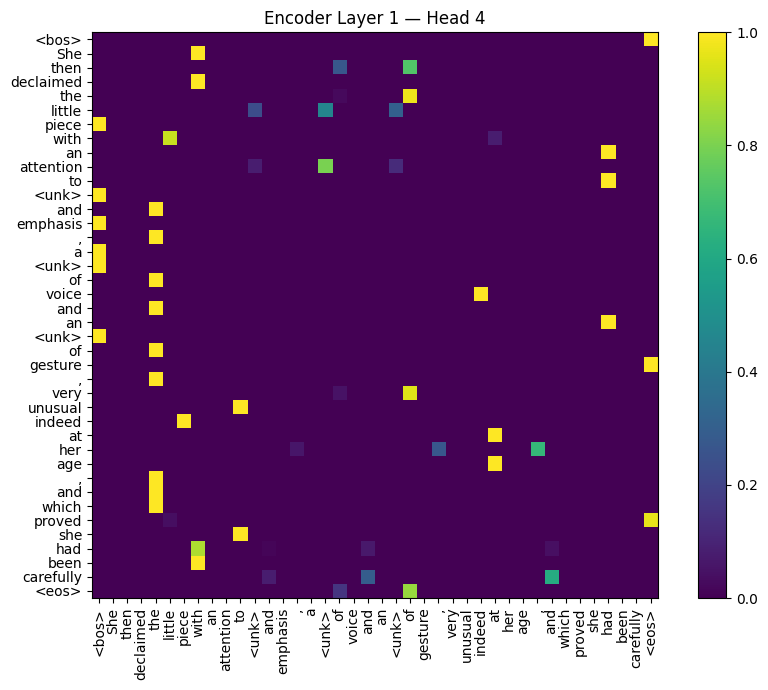

In [201]:
layer_number = 0

for head in range(
    NUM_HEADS
):

    matrix = (
        encoder_attention_maps[
            layer_number
        ][
            0,
            head,
            :actual_length,
            :actual_length
        ]
        .detach()
        .cpu()
    )

    plt.figure(
        figsize=(9, 7)
    )

    plt.imshow(
        matrix
    )

    plt.xticks(
        range(actual_length),
        source_words,
        rotation=90
    )

    plt.yticks(
        range(actual_length),
        source_words
    )

    plt.title(
        f"Encoder Layer 1 — Head {head + 1}"
    )

    plt.colorbar()

    plt.tight_layout()

    plt.show()

# **41. Compare Encoder Layers**

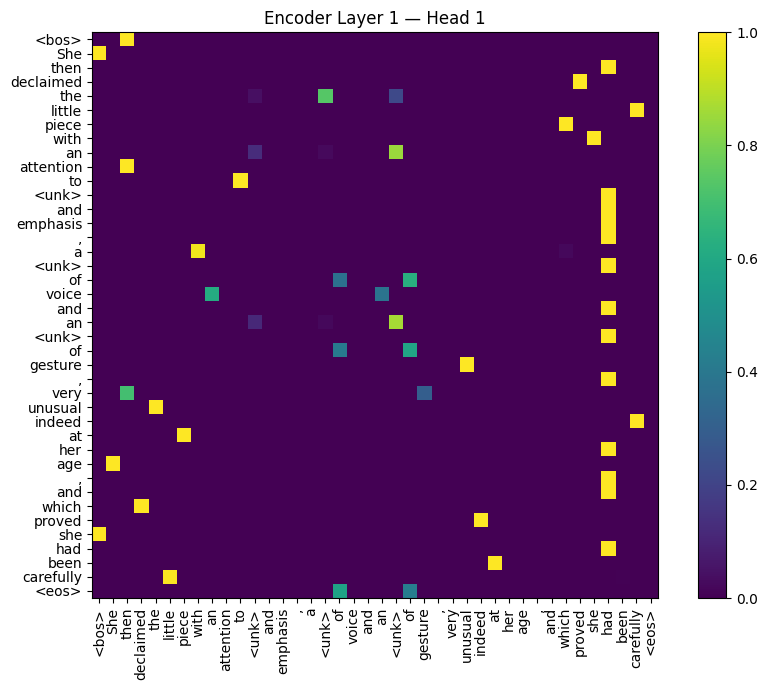

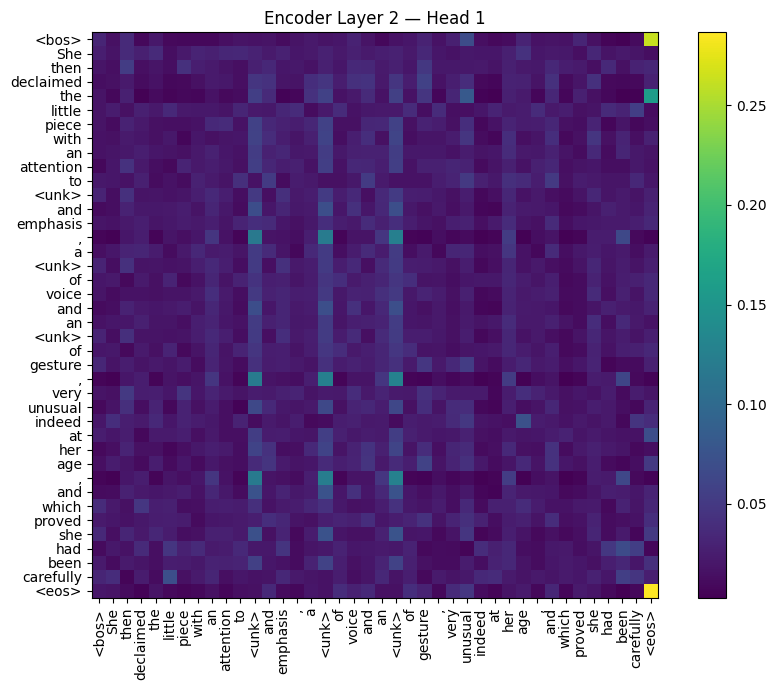

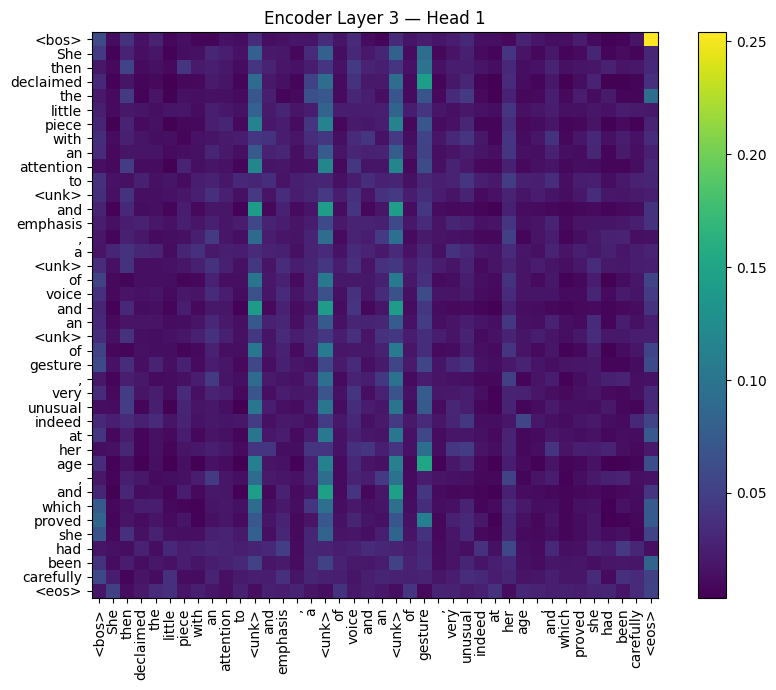

In [202]:
head_number = 0

for layer in range(
    NUM_ENCODER_LAYERS
):

    matrix = (
        encoder_attention_maps[
            layer
        ][
            0,
            head_number,
            :actual_length,
            :actual_length
        ]
        .detach()
        .cpu()
    )

    plt.figure(
        figsize=(9, 7)
    )

    plt.imshow(
        matrix
    )

    plt.xticks(
        range(actual_length),
        source_words,
        rotation=90
    )

    plt.yticks(
        range(actual_length),
        source_words
    )

    plt.title(
        f"Encoder Layer {layer + 1} — Head 1"
    )

    plt.colorbar()

    plt.tight_layout()

    plt.show()

# **42. Visualize Cross-Attention**

In [203]:
cross_sentence = (
    attention_source_text
)

cross_translation, cross_ids = (
    greedy_translate(
        model,
        cross_sentence,
        english_tokenizer,
        german_tokenizer,
        MAX_LEN,
        device
    )
)

print(
    "English:"
)

print(
    cross_sentence
)

print(
    "\nGenerated German:"
)

print(
    cross_translation
)

English:
She then declaimed the little piece with an attention to punctuation and emphasis, a flexibility of voice and an appropriateness of gesture, very unusual indeed at her age, and which proved she had been carefully trained.

Generated German:
Die und , und sie sich mit dem und und und und und und und und und , und , und , und


*Rebuild generated decoder input*

In [204]:
generated_decoder_ids = (
    [TGT_BOS_ID]
    + cross_ids
)

generated_decoder_tensor = torch.tensor(
    [generated_decoder_ids],
    dtype=torch.long,
    device=device
)

print(
    generated_decoder_tensor.shape
)

torch.Size([1, 38])


*Get decoder cross-attention maps*

In [205]:
generated_tgt_mask = create_target_mask(
    generated_decoder_tensor,
    TGT_PAD_ID
)

with torch.no_grad():

    (
        logits,
        _,
        decoder_self_attention_maps,
        decoder_cross_attention_maps
    ) = model(
        attention_src,
        generated_decoder_tensor,
        src_mask=attention_src_mask,
        tgt_mask=generated_tgt_mask
    )

print(
    "Decoder layers:",
    len(
        decoder_cross_attention_maps
    )
)

print(
    "Cross attention shape:",
    decoder_cross_attention_maps[
        0
    ].shape
)

Decoder layers: 3
Cross attention shape: torch.Size([1, 4, 38, 40])


*Get German token labels*

In [206]:
target_words = [
    BOS_TOKEN
]

for token_id in cross_ids:

    token = german_tokenizer.id_to_token(
        token_id
    )

    target_words.append(
        token
    )

print(
    target_words
)

['<bos>', 'Die', '<unk>', 'und', '<unk>', ',', 'und', 'sie', 'sich', 'mit', 'dem', '<unk>', 'und', '<unk>', 'und', '<unk>', 'und', '<unk>', 'und', '<unk>', 'und', '<unk>', 'und', '<unk>', 'und', '<unk>', 'und', '<unk>', 'und', '<unk>', ',', 'und', '<unk>', ',', 'und', '<unk>', ',', 'und']


*plot cross attention*

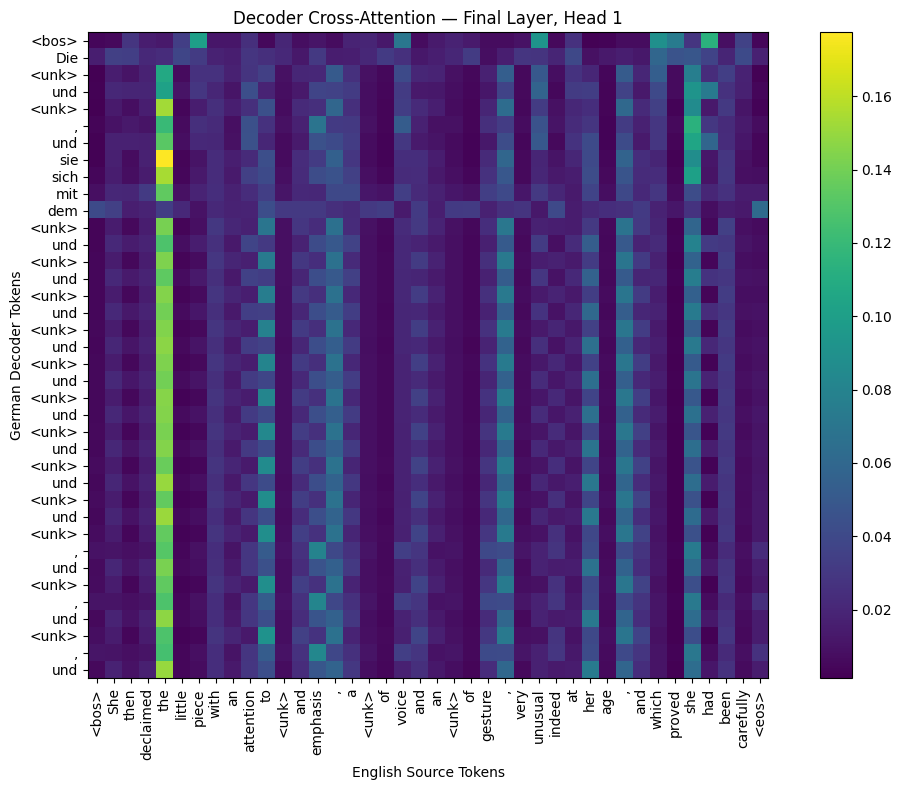

In [207]:
target_length = len(
    target_words
)

source_length = len(
    source_words
)

cross_matrix = (
    decoder_cross_attention_maps[
        -1
    ][
        0,
        0,
        :target_length,
        :source_length
    ]
    .detach()
    .cpu()
)

plt.figure(
    figsize=(11, 8)
)

plt.imshow(
    cross_matrix
)

plt.xticks(
    range(source_length),
    source_words,
    rotation=90
)

plt.yticks(
    range(target_length),
    target_words
)

plt.xlabel(
    "English Source Tokens"
)

plt.ylabel(
    "German Decoder Tokens"
)

plt.title(
    "Decoder Cross-Attention — Final Layer, Head 1"
)

plt.colorbar()

plt.tight_layout()

plt.show()

# **43. Save Experimental Results**

In [208]:
baseline_results = {
    "model": "Scaled Transformer Baseline",

    "dataset": "OPUS Books EN-DE",

    "train_examples":
        len(train_dataset),

    "validation_examples":
        len(validation_dataset),

    "test_examples":
        len(test_dataset),

    "d_model":
        D_MODEL,

    "heads":
        NUM_HEADS,

    "d_ff":
        D_FF,

    "encoder_layers":
        NUM_ENCODER_LAYERS,

    "decoder_layers":
        NUM_DECODER_LAYERS,

    "warmup_steps":
        WARMUP_STEPS,

    "label_smoothing":
        0.1,

    "test_loss":
        float(test_loss),

    "bleu":
        float(baseline_bleu),

    "parameters":
        sum(
            p.numel()
            for p in model.parameters()
        )
}

baseline_results

{'model': 'Scaled Transformer Baseline',
 'dataset': 'OPUS Books EN-DE',
 'train_examples': 18000,
 'validation_examples': 1000,
 'test_examples': 1000,
 'd_model': 128,
 'heads': 4,
 'd_ff': 512,
 'encoder_layers': 3,
 'decoder_layers': 3,
 'warmup_steps': 4000,
 'label_smoothing': 0.1,
 'test_loss': 5.959440723061562,
 'bleu': 0.512392286142646,
 'parameters': 6995034}

*Turn baseline into a table*

In [209]:
baseline_df = pd.DataFrame(
    [
        baseline_results
    ]
)

baseline_df

,model,dataset,train_examples,validation_examples,test_examples,d_model,heads,d_ff,encoder_layers,decoder_layers,warmup_steps,label_smoothing,test_loss,bleu,parameters
0,Scaled Transformer Baseline,OPUS Books EN-DE,18000,1000,1000,128,4,512,3,3,4000,0.1,5.959441,0.512392,6995034


# **44. Attention-Head Ablation**

*Set experiment controls*

In [210]:
ABLATION_EPOCHS = 2

HEAD_CONFIGS = [
    1,
    2,
    4
]

print("Head configurations:", HEAD_CONFIGS)
print("Epochs per experiment:", ABLATION_EPOCHS)

Head configurations: [1, 2, 4]
Epochs per experiment: 2


*Make experiments reproducible*

In [211]:
import random
import numpy as np

def set_seed(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

*Create BLEU evaluation function*

In [212]:
def evaluate_bleu(
    model,
    dataset,
    num_examples=200
):

    predictions = []
    references = []

    number_to_test = min(
        num_examples,
        len(dataset)
    )

    for i in tqdm(
        range(number_to_test),
        desc="BLEU Evaluation"
    ):

        example = dataset[i]

        source = (
            example["translation"]["en"]
        )

        reference = (
            example["translation"]["de"]
        )

        prediction, _ = greedy_translate(
            model,
            source,
            english_tokenizer,
            german_tokenizer,
            MAX_LEN,
            device
        )

        predictions.append(
            prediction
        )

        references.append(
            reference
        )

    result = sacrebleu.corpus_bleu(
        predictions,
        [references]
    )

    return result.score

*Create one reusable experiment function*

In [213]:
def run_head_experiment(
    num_heads,
    epochs=2
):

    print("\n" + "=" * 70)
    print(
        f"EXPERIMENT: {num_heads} ATTENTION HEAD(S)"
    )
    print("=" * 70)


    # -------------------------
    # Reproducibility
    # -------------------------

    set_seed(42)


    # -------------------------
    # New model
    # -------------------------

    experiment_model = Transformer(
        src_vocab_size=SRC_VOCAB_SIZE,
        tgt_vocab_size=TGT_VOCAB_SIZE,

        d_model=D_MODEL,
        num_heads=num_heads,
        d_ff=D_FF,

        num_encoder_layers=
            NUM_ENCODER_LAYERS,

        num_decoder_layers=
            NUM_DECODER_LAYERS,

        max_len=MAX_LEN,
        dropout=DROPOUT
    ).to(device)


    # -------------------------
    # Parameter count
    # -------------------------

    parameter_count = sum(
        p.numel()
        for p in experiment_model.parameters()
    )


    print(
        f"Parameters: {parameter_count:,}"
    )

    print(
        "Dimension per head:",
        D_MODEL // num_heads
    )


    # -------------------------
    # Optimizer
    # -------------------------

    experiment_optimizer = (
        torch.optim.Adam(
            experiment_model.parameters(),

            lr=0.0,

            betas=(
                0.9,
                0.98
            ),

            eps=1e-9
        )
    )


    global_step = 0

    experiment_train_losses = []
    experiment_val_losses = []


    # -------------------------
    # Training
    # -------------------------

    for epoch in range(
        1,
        epochs + 1
    ):

        print(
            f"\nEpoch {epoch}/{epochs}"
        )


        train_loss, global_step = (
            train_one_epoch(
                experiment_model,
                train_loader,
                experiment_optimizer,
                criterion,
                device,
                global_step,
                D_MODEL,
                WARMUP_STEPS
            )
        )


        val_loss = validate(
            experiment_model,
            validation_loader,
            criterion,
            device
        )


        experiment_train_losses.append(
            train_loss
        )

        experiment_val_losses.append(
            val_loss
        )


        print(
            f"Train loss: {train_loss:.4f}"
        )

        print(
            f"Validation loss: {val_loss:.4f}"
        )


    # -------------------------
    # Test Loss
    # -------------------------

    test_loss = validate(
        experiment_model,
        test_loader,
        criterion,
        device
    )


    # -------------------------
    # BLEU
    # -------------------------

    bleu = evaluate_bleu(
        experiment_model,
        test_dataset,
        num_examples=200
    )


    print(
        f"\nTest Loss: {test_loss:.4f}"
    )

    print(
        f"BLEU: {bleu:.2f}"
    )


    # -------------------------
    # Save result
    # -------------------------

    result = {

        "heads":
            num_heads,

        "d_model":
            D_MODEL,

        "d_k":
            D_MODEL // num_heads,

        "parameters":
            parameter_count,

        "epochs":
            epochs,

        "train_loss":
            experiment_train_losses[-1],

        "validation_loss":
            experiment_val_losses[-1],

        "test_loss":
            test_loss,

        "bleu":
            bleu
    }


    return (
        experiment_model,
        result,
        experiment_train_losses,
        experiment_val_losses
    )

# **45. Experiment 1: One Attention Head**

In [214]:
gc.collect()
torch.cuda.empty_cache()

print("GPU ready")

GPU ready


*Train 1-head model*

In [215]:
(
    model_heads_1,
    result_heads_1,
    train_heads_1,
    val_heads_1
) = run_head_experiment(
    num_heads=1,
    epochs=ABLATION_EPOCHS
)


EXPERIMENT: 1 ATTENTION HEAD(S)
Parameters: 6,995,034
Dimension per head: 128

Epoch 1/2


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train loss: 7.8918
Validation loss: 6.4730

Epoch 2/2


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train loss: 6.3789
Validation loss: 5.9782


Validation:   0%|          | 0/32 [00:00<?, ?it/s]

BLEU Evaluation:   0%|          | 0/200 [00:00<?, ?it/s]


Test Loss: 5.9807
BLEU: 0.66


In [216]:
print(
    result_heads_1
)

{'heads': 1, 'd_model': 128, 'd_k': 128, 'parameters': 6995034, 'epochs': 2, 'train_loss': 6.378917074118795, 'validation_loss': 5.978219375014305, 'test_loss': 5.98074696958065, 'bleu': 0.6564222611414963}


# **46. Experiment 2: Two Attention Heads**

In [217]:
del model_heads_1

gc.collect()
torch.cuda.empty_cache()

print(
    "1-head model removed from GPU"
)

1-head model removed from GPU


*Train 2-head model*

In [218]:
(
    model_heads_2,
    result_heads_2,
    train_heads_2,
    val_heads_2
) = run_head_experiment(
    num_heads=2,
    epochs=ABLATION_EPOCHS
)


EXPERIMENT: 2 ATTENTION HEAD(S)
Parameters: 6,995,034
Dimension per head: 64

Epoch 1/2


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train loss: 7.8929
Validation loss: 6.4641

Epoch 2/2


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train loss: 6.3692
Validation loss: 5.9734


Validation:   0%|          | 0/32 [00:00<?, ?it/s]

BLEU Evaluation:   0%|          | 0/200 [00:00<?, ?it/s]


Test Loss: 5.9718
BLEU: 0.53


In [219]:
print(
    result_heads_2
)

{'heads': 2, 'd_model': 128, 'd_k': 64, 'parameters': 6995034, 'epochs': 2, 'train_loss': 6.369241367224902, 'validation_loss': 5.973386883735657, 'test_loss': 5.9718212485313416, 'bleu': 0.5250469378289476}


# **47. What about the 4-head model?**

*Remove 2-head model*

In [220]:
del model_heads_2

gc.collect()
torch.cuda.empty_cache()

print(
    "2-head model removed from GPU"
)

2-head model removed from GPU


*Train controlled 4-head model*

In [221]:
(
    model_heads_4,
    result_heads_4,
    train_heads_4,
    val_heads_4
) = run_head_experiment(
    num_heads=4,
    epochs=ABLATION_EPOCHS
)


EXPERIMENT: 4 ATTENTION HEAD(S)
Parameters: 6,995,034
Dimension per head: 32

Epoch 1/2


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train loss: 7.8952
Validation loss: 6.4692

Epoch 2/2


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train loss: 6.3618
Validation loss: 5.9620


Validation:   0%|          | 0/32 [00:00<?, ?it/s]

BLEU Evaluation:   0%|          | 0/200 [00:00<?, ?it/s]


Test Loss: 5.9580
BLEU: 0.62


In [222]:
print(
    result_heads_4
)

{'heads': 4, 'd_model': 128, 'd_k': 32, 'parameters': 6995034, 'epochs': 2, 'train_loss': 6.361776157975409, 'validation_loss': 5.96195225417614, 'test_loss': 5.958037033677101, 'bleu': 0.6176416007959598}


# **48. Compare the Results**

Build experiment table

In [223]:
head_ablation_results = [
    result_heads_1,
    result_heads_2,
    result_heads_4
]

head_ablation_df = pd.DataFrame(
    head_ablation_results
)

head_ablation_df

,heads,d_model,d_k,parameters,epochs,train_loss,validation_loss,test_loss,bleu
0,1,128,128,6995034,2,6.378917,5.978219,5.980747,0.656422
1,2,128,64,6995034,2,6.369241,5.973387,5.971821,0.525047
2,4,128,32,6995034,2,6.361776,5.961952,5.958037,0.617642


*Compare BLEU*

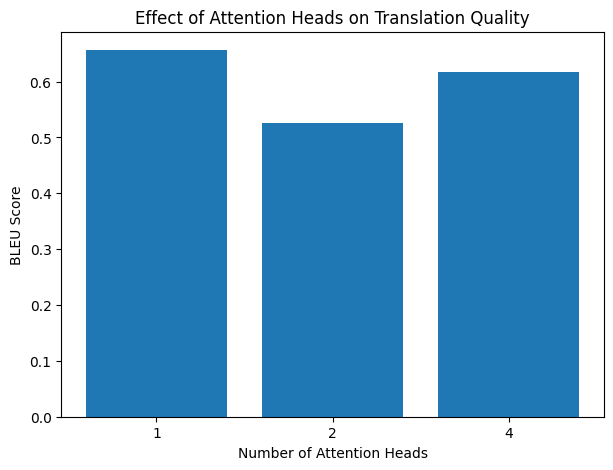

In [224]:
plt.figure(
    figsize=(7, 5)
)

plt.bar(
    head_ablation_df[
        "heads"
    ].astype(str),

    head_ablation_df[
        "bleu"
    ]
)

plt.xlabel(
    "Number of Attention Heads"
)

plt.ylabel(
    "BLEU Score"
)

plt.title(
    "Effect of Attention Heads on Translation Quality"
)

plt.show()

*Compare validation loss*

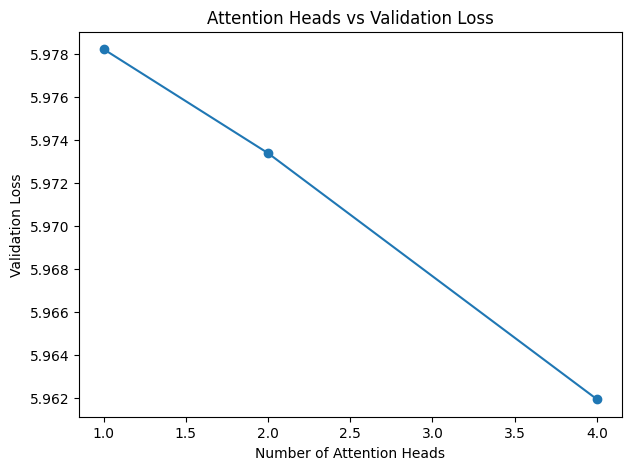

In [225]:
plt.figure(
    figsize=(7, 5)
)

plt.plot(
    head_ablation_df["heads"],
    head_ablation_df[
        "validation_loss"
    ],
    marker="o"
)

plt.xlabel(
    "Number of Attention Heads"
)

plt.ylabel(
    "Validation Loss"
)

plt.title(
    "Attention Heads vs Validation Loss"
)

plt.show()

*Compare training curves*

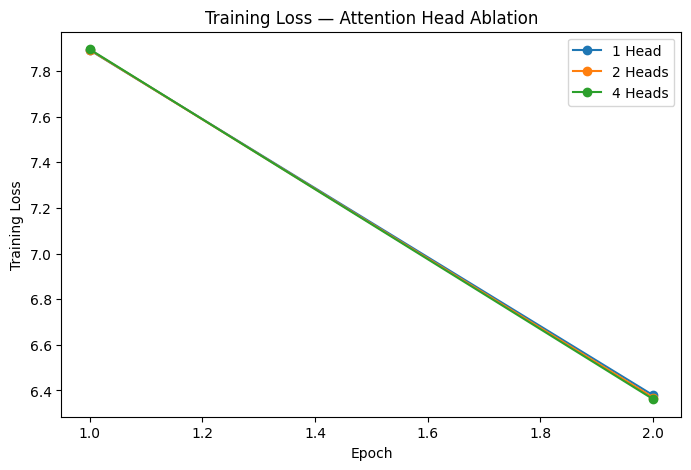

In [226]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(
        1,
        len(train_heads_1) + 1
    ),
    train_heads_1,
    marker="o",
    label="1 Head"
)

plt.plot(
    range(
        1,
        len(train_heads_2) + 1
    ),
    train_heads_2,
    marker="o",
    label="2 Heads"
)

plt.plot(
    range(
        1,
        len(train_heads_4) + 1
    ),
    train_heads_4,
    marker="o",
    label="4 Heads"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Training Loss — Attention Head Ablation"
)

plt.legend()

plt.show()

# **49. A subtle but VERY useful observation**

In [227]:
head_ablation_df[
    [
        "heads",
        "d_k",
        "parameters"
    ]
]

,heads,d_k,parameters
0,1,128,6995034
1,2,64,6995034
2,4,32,6995034


# **50. Automatically determine the best result**

In [228]:
best_head_result = (
    head_ablation_df
    .sort_values(
        "bleu",
        ascending=False
    )
    .iloc[0]
)

print(
    "Best number of heads:",
    int(
        best_head_result["heads"]
    )
)

print(
    "Best BLEU:",
    best_head_result["bleu"]
)

print(
    "Validation Loss:",
    best_head_result[
        "validation_loss"
    ]
)

Best number of heads: 1
Best BLEU: 0.6564222611414963
Validation Loss: 5.978219375014305


# **51. Write an experimental conclusion automatically**

In [229]:
best_heads = int(
    best_head_result[
        "heads"
    ]
)

best_bleu = float(
    best_head_result[
        "bleu"
    ]
)

print(
    f"""
Attention Head Ablation

We compared 1, 2, and 4 attention heads while
holding d_model={D_MODEL}, d_ff={D_FF},
the number of encoder/decoder layers, training
data, optimizer and training duration constant.

The highest BLEU score in this scaled experiment
was {best_bleu:.2f}, achieved with {best_heads}
attention head(s).

These results apply to our scaled OPUS Books
training setup and should not be interpreted as
contradicting the configuration selected for the
full-scale Transformer experiments in the
original paper.
"""
)


Attention Head Ablation

We compared 1, 2, and 4 attention heads while
holding d_model=128, d_ff=512,
the number of encoder/decoder layers, training
data, optimizer and training duration constant.

The highest BLEU score in this scaled experiment
was 0.66, achieved with 1
attention head(s).

These results apply to our scaled OPUS Books
training setup and should not be interpreted as
contradicting the configuration selected for the
full-scale Transformer experiments in the
original paper.




# **52. Positional Encoding Ablation**

*Create a “No Positional Encoding” module*

In [230]:
class NoPositionalEncoding(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x

*Create Encoder without positional encoding*

In [231]:
class EncoderModelNoPE(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_layers,
        max_len=5000,
        dropout=0.1
    ):
        super().__init__()

        self.d_model = d_model

        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.positional_encoding = (
            NoPositionalEncoding()
        )

        base_layer = EncoderLayer(
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout
        )

        self.encoder = Encoder(
            encoder_layer=base_layer,
            num_layers=num_layers
        )

    def forward(
        self,
        src,
        mask=None
    ):

        x = self.embedding(src)

        x = x * math.sqrt(
            self.d_model
        )

        x = self.positional_encoding(x)

        x, attention_maps = (
            self.encoder(
                x,
                mask
            )
        )

        return (
            x,
            attention_maps
        )

*Create Decoder without positional encoding*

In [232]:
class DecoderModelNoPE(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_layers,
        max_len=5000,
        dropout=0.1
    ):
        super().__init__()

        self.d_model = d_model

        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.positional_encoding = (
            NoPositionalEncoding()
        )

        base_layer = DecoderLayer(
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout
        )

        self.decoder = Decoder(
            decoder_layer=base_layer,
            num_layers=num_layers
        )

    def forward(
        self,
        tgt,
        encoder_output,
        tgt_mask=None,
        src_mask=None
    ):

        x = self.embedding(tgt)

        x = x * math.sqrt(
            self.d_model
        )

        x = self.positional_encoding(x)

        (
            x,
            self_attention_maps,
            cross_attention_maps
        ) = self.decoder(
            x,
            encoder_output,
            tgt_mask,
            src_mask
        )

        return (
            x,
            self_attention_maps,
            cross_attention_maps
        )

*Build complete Transformer without PE*

In [233]:
class TransformerNoPE(nn.Module):

    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model=128,
        num_heads=4,
        d_ff=512,
        num_encoder_layers=3,
        num_decoder_layers=3,
        max_len=40,
        dropout=0.1
    ):
        super().__init__()

        self.encoder = EncoderModelNoPE(
            vocab_size=src_vocab_size,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            num_layers=num_encoder_layers,
            max_len=max_len,
            dropout=dropout
        )

        self.decoder = DecoderModelNoPE(
            vocab_size=tgt_vocab_size,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            num_layers=num_decoder_layers,
            max_len=max_len,
            dropout=dropout
        )

        self.output_projection = nn.Linear(
            d_model,
            tgt_vocab_size
        )

    def forward(
        self,
        src,
        tgt,
        src_mask=None,
        tgt_mask=None
    ):

        (
            encoder_output,
            encoder_maps
        ) = self.encoder(
            src,
            src_mask
        )

        (
            decoder_output,
            decoder_self_maps,
            decoder_cross_maps
        ) = self.decoder(
            tgt,
            encoder_output,
            tgt_mask,
            src_mask
        )

        logits = self.output_projection(
            decoder_output
        )

        return (
            logits,
            encoder_maps,
            decoder_self_maps,
            decoder_cross_maps
        )

# **53. Sanity check the no-PE model**

In [234]:
set_seed(42)

no_pe_test_model = TransformerNoPE(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,

    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,

    num_encoder_layers=
        NUM_ENCODER_LAYERS,

    num_decoder_layers=
        NUM_DECODER_LAYERS,

    max_len=MAX_LEN,
    dropout=DROPOUT
).to(device)

print(
    "No-PE model created"
)

No-PE model created


*Forward-pass test*

In [235]:
no_pe_test_model.eval()

with torch.no_grad():

    (
        no_pe_logits,
        _,
        _,
        _
    ) = no_pe_test_model(
        src_batch,
        tgt_batch,
        src_mask=src_mask,
        tgt_mask=tgt_mask
    )

print(
    "Output shape:",
    no_pe_logits.shape
)

print(
    "Contains NaN:",
    torch.isnan(
        no_pe_logits
    ).any().item()
)

Output shape: torch.Size([32, 40, 15834])
Contains NaN: False


# **54. Train the No-PE experiment**

In [236]:
set_seed(42)

model_no_pe = TransformerNoPE(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,

    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,

    num_encoder_layers=
        NUM_ENCODER_LAYERS,

    num_decoder_layers=
        NUM_DECODER_LAYERS,

    max_len=MAX_LEN,
    dropout=DROPOUT
).to(device)


optimizer_no_pe = torch.optim.Adam(
    model_no_pe.parameters(),
    lr=0.0,
    betas=(0.9, 0.98),
    eps=1e-9
)


no_pe_global_step = 0

no_pe_train_losses = []
no_pe_val_losses = []

In [237]:
for epoch in range(
    1,
    ABLATION_EPOCHS + 1
):

    print(
        f"\n===== NO-PE EPOCH "
        f"{epoch}/{ABLATION_EPOCHS} ====="
    )

    train_loss, no_pe_global_step = (
        train_one_epoch(
            model_no_pe,
            train_loader,
            optimizer_no_pe,
            criterion,
            device,
            no_pe_global_step,
            D_MODEL,
            WARMUP_STEPS
        )
    )

    val_loss = validate(
        model_no_pe,
        validation_loader,
        criterion,
        device
    )

    no_pe_train_losses.append(
        train_loss
    )

    no_pe_val_losses.append(
        val_loss
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )


===== NO-PE EPOCH 1/2 =====


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 7.8946
Validation Loss: 6.4667

===== NO-PE EPOCH 2/2 =====


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 6.3624
Validation Loss: 5.9678


*Measure No-PE test loss*

In [238]:
no_pe_test_loss = validate(
    model_no_pe,
    test_loader,
    criterion,
    device
)

print(
    f"No-PE Test Loss: "
    f"{no_pe_test_loss:.4f}"
)

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

No-PE Test Loss: 5.9634


*Measure No-PE BLEU*

In [239]:
no_pe_bleu = evaluate_bleu(
    model_no_pe,
    test_dataset,
    num_examples=200
)

print(
    f"No-PE BLEU: "
    f"{no_pe_bleu:.2f}"
)

BLEU Evaluation:   0%|          | 0/200 [00:00<?, ?it/s]

No-PE BLEU: 0.59


# **55. Compare your controlled baseline**

In [240]:
positional_ablation_results = [
    {
        "configuration":
            "Sinusoidal PE",

        "test_loss":
            result_heads_4[
                "test_loss"
            ],

        "bleu":
            result_heads_4[
                "bleu"
            ]
    },

    {
        "configuration":
            "No PE",

        "test_loss":
            no_pe_test_loss,

        "bleu":
            no_pe_bleu
    }
]

positional_ablation_df = (
    pd.DataFrame(
        positional_ablation_results
    )
)

positional_ablation_df

,configuration,test_loss,bleu
0,Sinusoidal PE,5.958037,0.617642
1,No PE,5.963387,0.587787


*BLEU comparison*

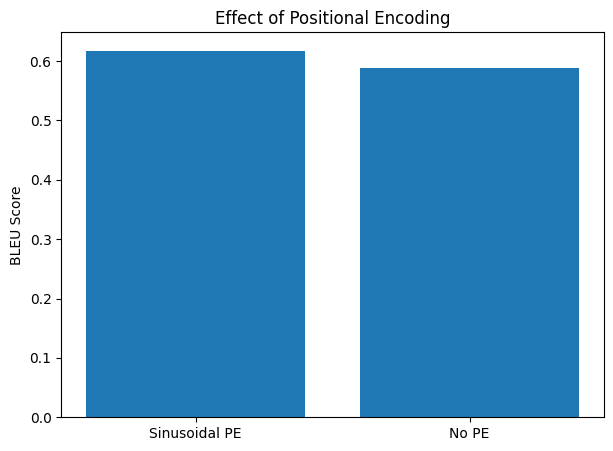

In [241]:
plt.figure(
    figsize=(7, 5)
)

plt.bar(
    positional_ablation_df[
        "configuration"
    ],

    positional_ablation_df[
        "bleu"
    ]
)

plt.ylabel(
    "BLEU Score"
)

plt.title(
    "Effect of Positional Encoding"
)

plt.show()

*Loss comparison*

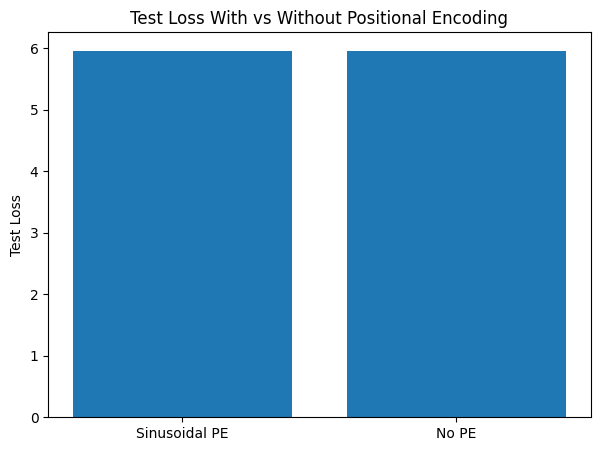

In [242]:
plt.figure(
    figsize=(7, 5)
)

plt.bar(
    positional_ablation_df[
        "configuration"
    ],

    positional_ablation_df[
        "test_loss"
    ]
)

plt.ylabel(
    "Test Loss"
)

plt.title(
    "Test Loss With vs Without Positional Encoding"
)

plt.show()

*Compare learning curves*

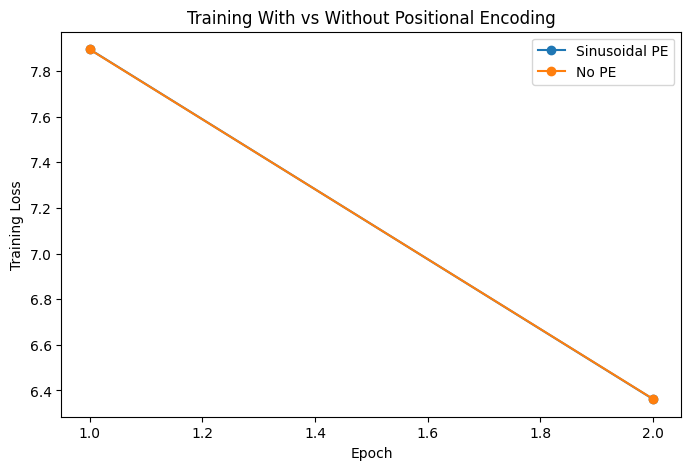

In [243]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(
        1,
        len(train_heads_4) + 1
    ),
    train_heads_4,
    marker="o",
    label="Sinusoidal PE"
)

plt.plot(
    range(
        1,
        len(no_pe_train_losses) + 1
    ),
    no_pe_train_losses,
    marker="o",
    label="No PE"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Loss"
)

plt.title(
    "Training With vs Without Positional Encoding"
)

plt.legend()

plt.show()

# **56. Why this experiment matters**

*Generate translations from both models*

In [244]:
comparison_sentence = (
    "The man opened the door."
)

In [245]:
baseline_translation, _ = (
    greedy_translate(
        model_heads_4,
        comparison_sentence,
        english_tokenizer,
        german_tokenizer,
        MAX_LEN,
        device
    )
)

In [246]:
#no positional encoding
no_pe_translation, _ = (
    greedy_translate(
        model_no_pe,
        comparison_sentence,
        english_tokenizer,
        german_tokenizer,
        MAX_LEN,
        device
    )
)

In [247]:
print(
    "SOURCE:"
)

print(
    comparison_sentence
)

print(
    "\nWITH POSITIONAL ENCODING:"
)

print(
    baseline_translation
)

print(
    "\nWITHOUT POSITIONAL ENCODING:"
)

print(
    no_pe_translation
)

SOURCE:
The man opened the door.

WITH POSITIONAL ENCODING:
Der .

WITHOUT POSITIONAL ENCODING:
Der .


# **57. Create experiment conclusion**

In [248]:
pe_bleu = float(
    result_heads_4["bleu"]
)

no_pe_bleu_value = float(
    no_pe_bleu
)

difference = (
    pe_bleu
    - no_pe_bleu_value
)

print(
    f"""
POSITIONAL ENCODING ABLATION

Sinusoidal PE BLEU:
{pe_bleu:.2f}

No positional encoding BLEU:
{no_pe_bleu_value:.2f}

BLEU difference:
{difference:.2f}
"""
)


POSITIONAL ENCODING ABLATION

Sinusoidal PE BLEU:
0.62

No positional encoding BLEU:
0.59

BLEU difference:
0.03



# **58. Save the result tables now**

In [249]:
head_ablation_df.to_csv(
    "head_ablation_results.csv",
    index=False
)

positional_ablation_df.to_csv(
    "positional_encoding_ablation.csv",
    index=False
)

print(
    "Experiment CSV files saved."
)

Experiment CSV files saved.


# **59. Warmup Ablation**

*Define warmup configurations*

In [250]:
WARMUP_CONFIGS = [
    400,
    1000,
    4000
]

WARMUP_ABLATION_EPOCHS = 2

print(
    "Warmup configurations:",
    WARMUP_CONFIGS
)

Warmup configurations: [400, 1000, 4000]


*Create reusable warmup experiment*

In [251]:
def run_warmup_experiment(
    warmup_steps,
    epochs=2
):

    print("\n" + "=" * 70)
    print(
        f"WARMUP EXPERIMENT: {warmup_steps} STEPS"
    )
    print("=" * 70)

    set_seed(42)

    experiment_model = Transformer(
        src_vocab_size=SRC_VOCAB_SIZE,
        tgt_vocab_size=TGT_VOCAB_SIZE,

        d_model=D_MODEL,
        num_heads=NUM_HEADS,
        d_ff=D_FF,

        num_encoder_layers=
            NUM_ENCODER_LAYERS,

        num_decoder_layers=
            NUM_DECODER_LAYERS,

        max_len=MAX_LEN,
        dropout=DROPOUT
    ).to(device)

    experiment_optimizer = torch.optim.Adam(
        experiment_model.parameters(),
        lr=0.0,
        betas=(0.9, 0.98),
        eps=1e-9
    )

    global_step = 0

    train_history = []
    val_history = []

    for epoch in range(
        1,
        epochs + 1
    ):

        print(
            f"\nEpoch {epoch}/{epochs}"
        )

        train_loss, global_step = (
            train_one_epoch(
                experiment_model,
                train_loader,
                experiment_optimizer,
                criterion,
                device,
                global_step,
                D_MODEL,
                warmup_steps
            )
        )

        val_loss = validate(
            experiment_model,
            validation_loader,
            criterion,
            device
        )

        train_history.append(
            train_loss
        )

        val_history.append(
            val_loss
        )

        print(
            f"Train Loss: {train_loss:.4f}"
        )

        print(
            f"Validation Loss: {val_loss:.4f}"
        )

    test_loss = validate(
        experiment_model,
        test_loader,
        criterion,
        device
    )

    bleu = evaluate_bleu(
        experiment_model,
        test_dataset,
        num_examples=200
    )

    parameter_count = sum(
        p.numel()
        for p in experiment_model.parameters()
    )

    result = {
        "warmup_steps":
            warmup_steps,

        "epochs":
            epochs,

        "parameters":
            parameter_count,

        "train_loss":
            train_history[-1],

        "validation_loss":
            val_history[-1],

        "test_loss":
            test_loss,

        "bleu":
            bleu
    }

    print(
        f"\nTest Loss: {test_loss:.4f}"
    )

    print(
        f"BLEU: {bleu:.2f}"
    )

    return (
        experiment_model,
        result,
        train_history,
        val_history
    )

# **60. Warmup = 400**

In [252]:
gc.collect()
torch.cuda.empty_cache()

In [253]:
(
    model_warmup_400,
    result_warmup_400,
    train_warmup_400,
    val_warmup_400
) = run_warmup_experiment(
    warmup_steps=400,
    epochs=WARMUP_ABLATION_EPOCHS
)


WARMUP EXPERIMENT: 400 STEPS

Epoch 1/2


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 6.5255
Validation Loss: 5.7595

Epoch 2/2


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 5.6995
Validation Loss: 5.4597


Validation:   0%|          | 0/32 [00:00<?, ?it/s]

BLEU Evaluation:   0%|          | 0/200 [00:00<?, ?it/s]


Test Loss: 5.4698
BLEU: 1.53


In [254]:
print(
    result_warmup_400
)

{'warmup_steps': 400, 'epochs': 2, 'parameters': 6995034, 'train_loss': 5.699498937142678, 'validation_loss': 5.459707260131836, 'test_loss': 5.469815775752068, 'bleu': 1.529094989848781}


# **61. Warmup = 1000**

In [255]:
del model_warmup_400

gc.collect()
torch.cuda.empty_cache()

In [256]:
(
    model_warmup_1000,
    result_warmup_1000,
    train_warmup_1000,
    val_warmup_1000
) = run_warmup_experiment(
    warmup_steps=1000,
    epochs=WARMUP_ABLATION_EPOCHS
)


WARMUP EXPERIMENT: 1000 STEPS

Epoch 1/2


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 6.8828
Validation Loss: 5.8791

Epoch 2/2


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 5.8446
Validation Loss: 5.5990


Validation:   0%|          | 0/32 [00:00<?, ?it/s]

BLEU Evaluation:   0%|          | 0/200 [00:00<?, ?it/s]


Test Loss: 5.5987
BLEU: 1.46


In [257]:
print(
    result_warmup_1000
)

{'warmup_steps': 1000, 'epochs': 2, 'parameters': 6995034, 'train_loss': 5.844567769797615, 'validation_loss': 5.5990040153265, 'test_loss': 5.598659440875053, 'bleu': 1.45544275844086}


# **62. Warmup = 4000**

In [258]:
del model_warmup_1000

gc.collect()
torch.cuda.empty_cache()

In [259]:
(
    model_warmup_4000,
    result_warmup_4000,
    train_warmup_4000,
    val_warmup_4000
) = run_warmup_experiment(
    warmup_steps=4000,
    epochs=WARMUP_ABLATION_EPOCHS
)


WARMUP EXPERIMENT: 4000 STEPS

Epoch 1/2


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 7.8952
Validation Loss: 6.4692

Epoch 2/2


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 6.3618
Validation Loss: 5.9620


Validation:   0%|          | 0/32 [00:00<?, ?it/s]

BLEU Evaluation:   0%|          | 0/200 [00:00<?, ?it/s]


Test Loss: 5.9580
BLEU: 0.62


In [260]:
print(
    result_warmup_4000
)

{'warmup_steps': 4000, 'epochs': 2, 'parameters': 6995034, 'train_loss': 6.361776157975409, 'validation_loss': 5.96195225417614, 'test_loss': 5.958037033677101, 'bleu': 0.6176416007959598}


# **63. Compare warmup results**

In [261]:
warmup_results = [
    result_warmup_400,
    result_warmup_1000,
    result_warmup_4000
]

warmup_df = pd.DataFrame(
    warmup_results
)

warmup_df

,warmup_steps,epochs,parameters,train_loss,validation_loss,test_loss,bleu
0,400,2,6995034,5.699499,5.459707,5.469816,1.529095
1,1000,2,6995034,5.844568,5.599004,5.598659,1.455443
2,4000,2,6995034,6.361776,5.961952,5.958037,0.617642


*Plot BLEU vs warmup*

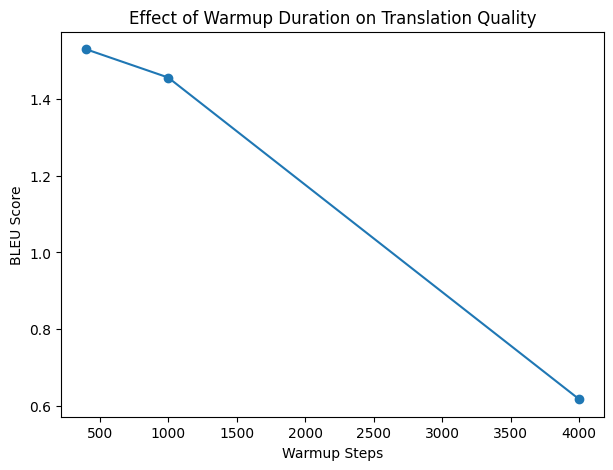

In [262]:
plt.figure(
    figsize=(7, 5)
)

plt.plot(
    warmup_df[
        "warmup_steps"
    ],

    warmup_df[
        "bleu"
    ],

    marker="o"
)

plt.xlabel(
    "Warmup Steps"
)

plt.ylabel(
    "BLEU Score"
)

plt.title(
    "Effect of Warmup Duration on Translation Quality"
)

plt.show()

*Plot validation loss*

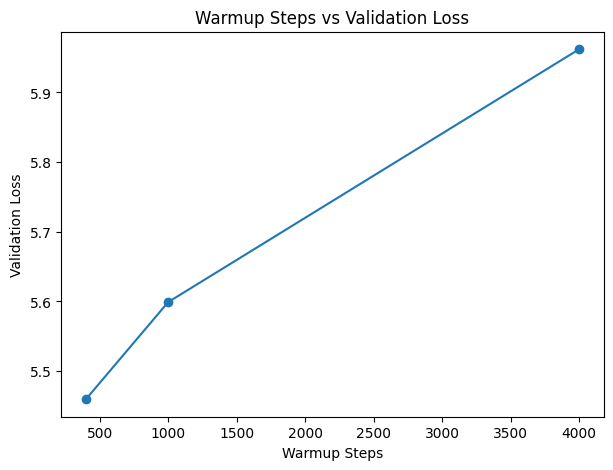

In [263]:
plt.figure(
    figsize=(7, 5)
)

plt.plot(
    warmup_df[
        "warmup_steps"
    ],

    warmup_df[
        "validation_loss"
    ],

    marker="o"
)

plt.xlabel(
    "Warmup Steps"
)

plt.ylabel(
    "Validation Loss"
)

plt.title(
    "Warmup Steps vs Validation Loss"
)

plt.show()

*Compare learning curves*

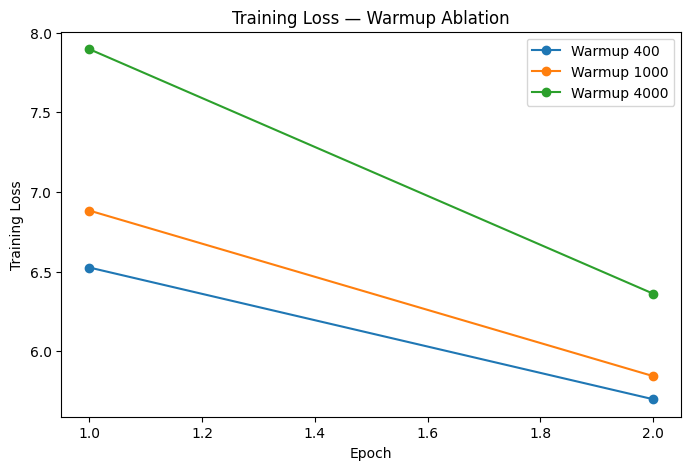

In [264]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(
        1,
        len(train_warmup_400) + 1
    ),
    train_warmup_400,
    marker="o",
    label="Warmup 400"
)

plt.plot(
    range(
        1,
        len(train_warmup_1000) + 1
    ),
    train_warmup_1000,
    marker="o",
    label="Warmup 1000"
)

plt.plot(
    range(
        1,
        len(train_warmup_4000) + 1
    ),
    train_warmup_4000,
    marker="o",
    label="Warmup 4000"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Loss"
)

plt.title(
    "Training Loss — Warmup Ablation"
)

plt.legend()

plt.show()

*Find best warmup*

In [265]:
best_warmup_result = (
    warmup_df
    .sort_values(
        "bleu",
        ascending=False
    )
    .iloc[0]
)

print(
    "Best warmup steps:",
    int(
        best_warmup_result[
            "warmup_steps"
        ]
    )
)

print(
    "Best BLEU:",
    best_warmup_result[
        "bleu"
    ]
)

Best warmup steps: 400
Best BLEU: 1.529094989848781


*Save warmup results*

In [266]:
warmup_df.to_csv(
    "warmup_ablation_results.csv",
    index=False
)

print(
    "Warmup ablation saved."
)

Warmup ablation saved.


# **64. Build ONE final experiment summary table**

In [267]:
summary_rows = []

for _, row in head_ablation_df.iterrows():

    summary_rows.append(
        {
            "experiment":
                f"Heads={int(row['heads'])}",

            "BLEU":
                row["bleu"],

            "Test Loss":
                row["test_loss"]
        }
    )


for _, row in positional_ablation_df.iterrows():

    summary_rows.append(
        {
            "experiment":
                row["configuration"],

            "BLEU":
                row["bleu"],

            "Test Loss":
                row["test_loss"]
        }
    )


for _, row in warmup_df.iterrows():

    summary_rows.append(
        {
            "experiment":
                f"Warmup={int(row['warmup_steps'])}",

            "BLEU":
                row["bleu"],

            "Test Loss":
                row["test_loss"]
        }
    )


experiment_summary_df = (
    pd.DataFrame(
        summary_rows
    )
)

experiment_summary_df

,experiment,BLEU,Test Loss
0,Heads=1,0.656422,5.980747
1,Heads=2,0.525047,5.971821
2,Heads=4,0.617642,5.958037
3,Sinusoidal PE,0.617642,5.958037
4,No PE,0.587787,5.963387
5,Warmup=400,1.529095,5.469816
6,Warmup=1000,1.455443,5.598659
7,Warmup=4000,0.617642,5.958037


*save full summary*

In [268]:
experiment_summary_df.to_csv(
    "experiment_summary.csv",
    index=False
)

print(
    "Full experiment summary saved."
)

Full experiment summary saved.


# **65. Paper vs Our Reproduction**

In [269]:
paper_comparison = pd.DataFrame(
    [
        {
            "Component":
                "Dataset",

            "Original Paper":
                "WMT English-German",

            "Our Reproduction":
                "OPUS Books EN-DE subset"
        },

        {
            "Component":
                "d_model",

            "Original Paper":
                512,

            "Our Reproduction":
                D_MODEL
        },

        {
            "Component":
                "Attention Heads",

            "Original Paper":
                8,

            "Our Reproduction":
                NUM_HEADS
        },

        {
            "Component":
                "d_ff",

            "Original Paper":
                2048,

            "Our Reproduction":
                D_FF
        },

        {
            "Component":
                "Encoder Layers",

            "Original Paper":
                6,

            "Our Reproduction":
                NUM_ENCODER_LAYERS
        },

        {
            "Component":
                "Decoder Layers",

            "Original Paper":
                6,

            "Our Reproduction":
                NUM_DECODER_LAYERS
        },

        {
            "Component":
                "Dropout",

            "Original Paper":
                0.1,

            "Our Reproduction":
                DROPOUT
        },

        {
            "Component":
                "Warmup",

            "Original Paper":
                4000,

            "Our Reproduction":
                WARMUP_STEPS
        },

        {
            "Component":
                "Label Smoothing",

            "Original Paper":
                0.1,

            "Our Reproduction":
                0.1
        },

        {
            "Component":
                "Hardware",

            "Original Paper":
                "Multi-GPU training",

            "Our Reproduction":
                "Google Colab T4"
        }
    ]
)

paper_comparison

,Component,Original Paper,Our Reproduction
0,Dataset,WMT English-German,OPUS Books EN-DE subset
1,d_model,512,128
2,Attention Heads,8,4
3,d_ff,2048,512
4,Encoder Layers,6,3
5,Decoder Layers,6,3
6,Dropout,0.1,0.1
7,Warmup,4000,4000
8,Label Smoothing,0.1,0.1
9,Hardware,Multi-GPU training,Google Colab T4


In [270]:
paper_comparison.to_csv(
    "paper_vs_scaled_reproduction.csv",
    index=False
)

print(
    "Paper comparison saved."
)

Paper comparison saved.


*Updated EncoderModel*

In [271]:
class EncoderModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_layers,
        max_len=5000,
        dropout=0.1
    ):
        super().__init__()

        self.d_model = d_model

        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.positional_encoding = PositionalEncoding(
            d_model,
            max_len
        )

        # Paper-style dropout after
        # embedding + positional encoding
        self.embedding_dropout = nn.Dropout(
            dropout
        )

        base_layer = EncoderLayer(
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout
        )

        self.encoder = Encoder(
            encoder_layer=base_layer,
            num_layers=num_layers
        )

    def forward(
        self,
        src,
        mask=None
    ):

        x = self.embedding(src)

        x = x * math.sqrt(
            self.d_model
        )

        x = self.positional_encoding(
            x
        )

        x = self.embedding_dropout(
            x
        )

        x, attention_maps = (
            self.encoder(
                x,
                mask
            )
        )

        return (
            x,
            attention_maps
        )

*Updated DecoderModel*

In [272]:
class DecoderModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_layers,
        max_len=5000,
        dropout=0.1
    ):
        super().__init__()

        self.d_model = d_model

        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.positional_encoding = PositionalEncoding(
            d_model,
            max_len
        )

        self.embedding_dropout = nn.Dropout(
            dropout
        )

        base_layer = DecoderLayer(
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout
        )

        self.decoder = Decoder(
            decoder_layer=base_layer,
            num_layers=num_layers
        )

    def forward(
        self,
        tgt,
        encoder_output,
        tgt_mask=None,
        src_mask=None
    ):

        x = self.embedding(tgt)

        x = x * math.sqrt(
            self.d_model
        )

        x = self.positional_encoding(
            x
        )

        x = self.embedding_dropout(
            x
        )

        (
            x,
            self_attention_maps,
            cross_attention_maps
        ) = self.decoder(
            x,
            encoder_output,
            tgt_mask,
            src_mask
        )

        return (
            x,
            self_attention_maps,
            cross_attention_maps
        )

*Make sure final Transformer still works*

In [273]:
final_test_model = Transformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,

    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,

    num_encoder_layers=
        NUM_ENCODER_LAYERS,

    num_decoder_layers=
        NUM_DECODER_LAYERS,

    max_len=MAX_LEN,
    dropout=DROPOUT
).to(device)

In [274]:
final_test_model.eval()

with torch.no_grad():

    final_logits, _, _, _ = (
        final_test_model(
            src_batch,
            tgt_batch,
            src_mask=src_mask,
            tgt_mask=tgt_mask
        )
    )

print(
    "Shape:",
    final_logits.shape
)

print(
    "NaN:",
    torch.isnan(
        final_logits
    ).any().item()
)

print(
    "Parameters:",
    f"{sum(p.numel() for p in final_test_model.parameters()):,}"
)

Shape: torch.Size([32, 40, 15834])
NaN: False
Parameters: 6,995,034


*Once that works , del it*

In [275]:
del final_test_model

gc.collect()
torch.cuda.empty_cache()